# Results report: which scales matter for StreamDEQ's warm-start?

## Background

StreamDEQ speeds up video segmentation by reusing the previous frame's equilibrium state (`z*`) to warm-start each new frame's fixed-point solve, instead of solving from scratch every time. MDEQ's internal state is made of **4 multiscale branches** (finest to coarsest resolution, labeled scale 0-3). The full StreamDEQ method warm-starts all 4.

This project asks: **do all 4 scales need to be warm-started, or does only reusing some of them get most of the benefit?** To answer that, 340 evaluation runs were swept: every combination of

- **5 context lengths** (`1f, 2f, 5f, 10f, 20f`, how many frames of video precede the one being scored; longer contexts give the streaming state more frames to settle into before it's measured),
- **4 Broyden iteration budgets** (`1, 2, 4, 8`, how much solver compute is allowed per frame), and
- **17 initialization configurations** (which scales get warm-started that frame, described below).

All results are read live from `results_master.csv`, so this notebook can be re-run at any point to reflect the latest completed runs.

## How configurations are named

Every configuration name describes **which scales stay warm-started** (reuse the previous frame's equilibrium), any scale *not* listed is reset to zero for that frame instead. For example, `keeps 1,2,3` means scales 1, 2 and 3 reuse the previous frame's state, and scale 0 restarts cold every frame.

| Group | What it tests | Example names |
|---|---|---|
| **Phase 0 — global** | The two extremes, plus a staleness check | `streamdeq` (all 4 warm), `mdeq` (all 4 cold, no reuse at all), `stale_k2` (all 4 warm, but from 2 frames ago) |
| **Phase 1 — leave-1-out** | Reset exactly one scale, keep the other 3 | `keeps 1,2,3` (resets scale 0), and 3 more, one per scale |
| **Phase 1 — leave-2-out** | Keep exactly 2 scales, reset the other 2 | `keeps 1,3`, and the other 5 possible pairs |
| **Phase 1 — leave-3-out** | Keep only 1 scale, reset the other 3 | `keeps 1`, and one for each other scale |

Sections 1-3 look at all 17 configurations together (the big picture); Sections 4-9 isolate specific comparisons to answer "how important is each scale" from different angles; Sections 10-11 flip the axes to check whether context length or iteration budget change the story.

In [1]:
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

RESULTS_CSV = "results_master.csv"

sns.set_theme(style="whitegrid", font_scale=1.1)

# Same identity palette as in graphs.ipynb: each scale (0-3) always has the
# same color in any chart; 'previous'/'zero' are references (all scales vs.
# none), in neutral gray.
_colorblind = sns.color_palette("colorblind")
SCALE_COLORS = {0: _colorblind[0], 1: _colorblind[1], 2: _colorblind[2], 3: _colorblind[3]}
REFERENCE_COLORS = {"previous": "#4d4d4d", "zero": "#b0b0b0", "stale_k2": _colorblind[4]}

CONTEXT_ORDER = ["1f", "2f", "5f", "10f", "20f"]
ITER_ORDER = [1, 2, 4, 8]

## Loading the CSV and an organized view of progress

In [2]:
df = pd.read_csv(RESULTS_CSV)
df["context_n"] = df["context"].str.rstrip("f").astype(int)
df["broyden_iterations"] = df["broyden_iterations"].astype(int)
df = df.sort_values(["phase", "context_n", "init_name", "broyden_iterations"]).reset_index(drop=True)

print(f"{len(df)} rows loaded from {RESULTS_CSV}")

340 rows loaded from results_master.csv


Every chart in this report is built from `results_master.csv`, where **each row is one evaluation run** (one specific configuration, context length and iteration budget). The columns that matter here:

- `phase` — which experiment group the run belongs to (global baselines, leave-1/2/3-out, see the table in the introduction).
- `context` — how many priming frames preceded the scored one (`1f`...`20f`).
- `init_name` / `partial_init_mode` — the exact initialization mode tested; this is what the `keeps ...` labels used throughout this report are built from.
- `broyden_iterations` — the solver's iteration budget for that run.
- `miou` — the resulting mean IoU, the metric plotted in every figure below.

A random sample of rows, so the raw shape of the data is visible before it gets aggregated into charts:

In [3]:
df.sample(8, random_state=0).sort_values(["phase", "context_n", "init_name", "broyden_iterations"])

,phase,context,init_name,init_mode,partial_init_mode,broyden_iterations,miou,notes,context_n
15,phase0_global,2f,previous,previous,NaN,8,0.7827,original StreamDEQ warm-start,2
76,phase1_leave_one_scale,2f,drop_scale0_previous,partial,drop_scale0_previous,1,0.2439,1i YAML uses equivalent scale1_scale2_scale3_p...,2
204,phase1_three_scale,20f,only_scale0_previous,partial,only_high_resolution_previous,1,0.0203,"full_sweep_runner, 38.5 min",20
225,phase1_two_scale,1f,scale0_scale2_previous,partial,scale0_scale2_previous,2,0.1729,"full_sweep_runner, 10.6 min",1
271,phase1_two_scale,5f,scale0_scale1_previous,partial,fine_previous_coarse_zero,8,0.7567,"full_sweep_runner, 51.0 min",5
274,phase1_two_scale,5f,scale0_scale2_previous,partial,scale0_scale2_previous,4,0.5371,"full_sweep_runner, 44.7 min",5
278,phase1_two_scale,5f,scale0_scale3_previous,partial,scale0_scale3_previous,4,0.5115,"full_sweep_runner, 39.8 min",5
299,phase1_two_scale,10f,scale0_scale2_previous,partial,scale0_scale2_previous,8,0.7548,"full_sweep_runner, 86.4 min",10


And an organized view of coverage — how many of the 17 configurations have run, by context and iteration budget (17 is the maximum, one per configuration):

In [4]:
# Progress table: how many configurations have already run, by context and iterations.
progress = df.pivot_table(index="context", columns="broyden_iterations", values="miou", aggfunc="count", fill_value=0)
progress = progress.reindex(CONTEXT_ORDER)
progress.columns = [f"{c}i" for c in progress.columns]
progress.style.background_gradient(cmap="Greens", vmin=0, vmax=17).set_caption("Configurations run by context x iterations (out of 17 possible)")

,1i,2i,4i,8i
context,,,,
1f,17,17,17,17
2f,17,17,17,17
5f,17,17,17,17
10f,17,17,17,17
20f,17,17,17,17


## Style per configuration (reused across every curve in this notebook)

Every configuration name below describes **which scales stay warm-started** (i.e. reuse the previous frame's equilibrium), the rest are reset to zero for that frame. Each one gets a fixed color/line style, recognizable the same way in any chart from here on:

- `streamdeq` (dark gray, thick) and `mdeq` (light gray): all 4 scales warm-started (`streamdeq`) vs. none (`mdeq`, equivalent to running frame-by-frame with no reuse at all).
- `stale_k2` (dashed magenta): uses all 4 scales, but from frame t-2 instead of t-1.
- `keeps i,j,k` (leave-1-out, 3 scales warm): colored by the identity of the one scale that's *reset* (e.g. `keeps 1,2,3` resets scale 0).
- `keeps i,j` (leave-2-out, 2 scales warm): blend of the colors of scales i and j, dashed line, square marker.
- `keeps k` (leave-3-out, only 1 scale warm): color of scale k, dotted, triangle marker.

In [5]:
def blend(c1, c2):
    return tuple((a + b) / 2 for a, b in zip(c1, c2))

def config_style(phase, init_name):
    if phase == "phase0_global":
        if init_name == "previous":
            return "streamdeq", REFERENCE_COLORS["previous"], "-", "o", 2.5, 8
        if init_name == "zero":
            return "mdeq", REFERENCE_COLORS["zero"], "-", "o", 1.5, 6
        if init_name == "stale_k2":
            return "stale_k2 (t-2, all)", REFERENCE_COLORS["stale_k2"], "--", "D", 1.8, 6
    if phase == "phase1_leave_one_scale":
        k = int(re.search(r"drop_scale(\d)", init_name).group(1))
        kept = ",".join(str(s) for s in sorted(set(range(4)) - {k}))
        return f"keeps {kept}", SCALE_COLORS[k], "-", "o", 1.5, 6
    if phase == "phase1_two_scale":
        i, j = map(int, re.search(r"scale(\d)_scale(\d)_previous", init_name).groups())
        return f"keeps {i},{j}", blend(SCALE_COLORS[i], SCALE_COLORS[j]), "--", "s", 1.5, 6
    if phase == "phase1_three_scale":
        k = int(re.search(r"only_scale(\d)_previous", init_name).group(1))
        return f"keeps {k}", SCALE_COLORS[k], ":", "^", 1.5, 6
    raise ValueError((phase, init_name))

CONFIG_META = {
    (p, n): config_style(p, n)
    for p, n in df[["phase", "init_name"]].drop_duplicates().itertuples(index=False)
}

# Fixed legend order: references, leave-1-out, pairs (leave-2-out), leave-3-out.
LEGEND_ORDER = [
    ("phase0_global", "previous"),
    ("phase0_global", "stale_k2"),
    ("phase1_leave_one_scale", "drop_scale0_previous"),
    ("phase1_leave_one_scale", "drop_scale1_previous"),
    ("phase1_leave_one_scale", "drop_scale2_previous"),
    ("phase1_leave_one_scale", "drop_scale3_previous"),
    ("phase1_two_scale", "scale0_scale1_previous"),
    ("phase1_two_scale", "scale0_scale2_previous"),
    ("phase1_two_scale", "scale0_scale3_previous"),
    ("phase1_two_scale", "scale1_scale2_previous"),
    ("phase1_two_scale", "scale1_scale3_previous"),
    ("phase1_two_scale", "scale2_scale3_previous"),
    ("phase1_three_scale", "only_scale0_previous"),
    ("phase1_three_scale", "only_scale1_previous"),
    ("phase1_three_scale", "only_scale2_previous"),
    ("phase1_three_scale", "only_scale3_previous"),
    ("phase0_global", "zero"),
]
legend_keys = [k for k in LEGEND_ORDER if k in CONFIG_META]

def plot_configs(ax, data, keys):
    for phase, init_name in keys:
        sub = data[(data["phase"] == phase) & (data["init_name"] == init_name)].sort_values("context_n")
        if sub.empty:
            continue
        label, color, ls, marker, lw, ms = CONFIG_META[(phase, init_name)]
        ax.plot(sub["context_n"], sub["miou"], color=color, linestyle=ls, marker=marker,
                linewidth=lw, markersize=ms, label=label)

## 1. Master curve: all configurations, one large figure per iteration budget

X axis = context frames, y axis = mIoU. One full figure per Broyden budget (1i, 2i, 4i, 8i) instead of small subplots, so all 17 lines can be read clearly.

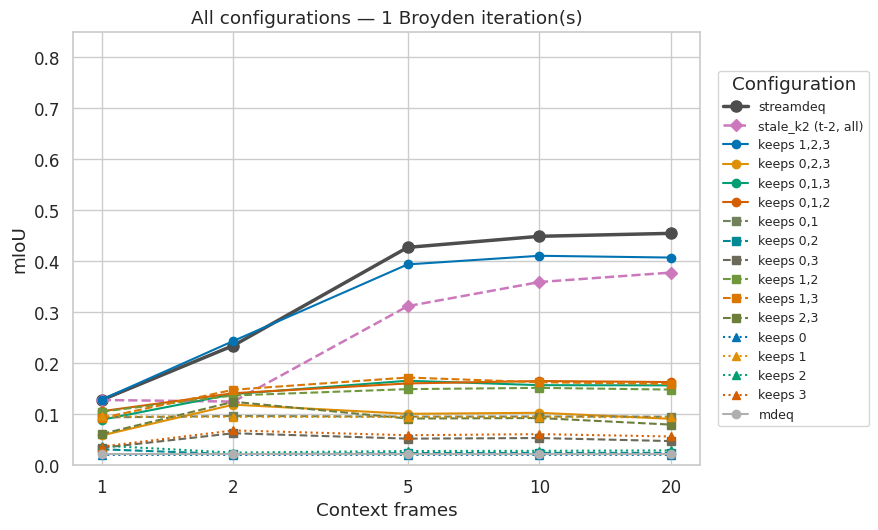

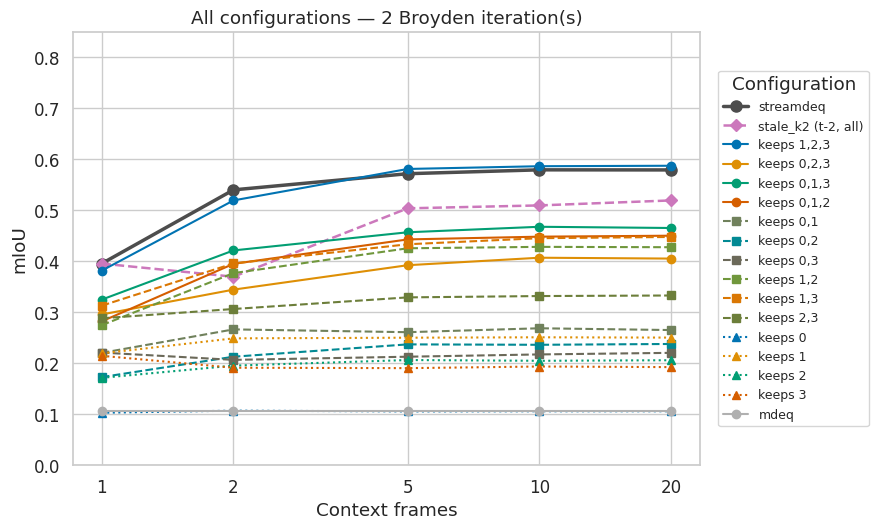

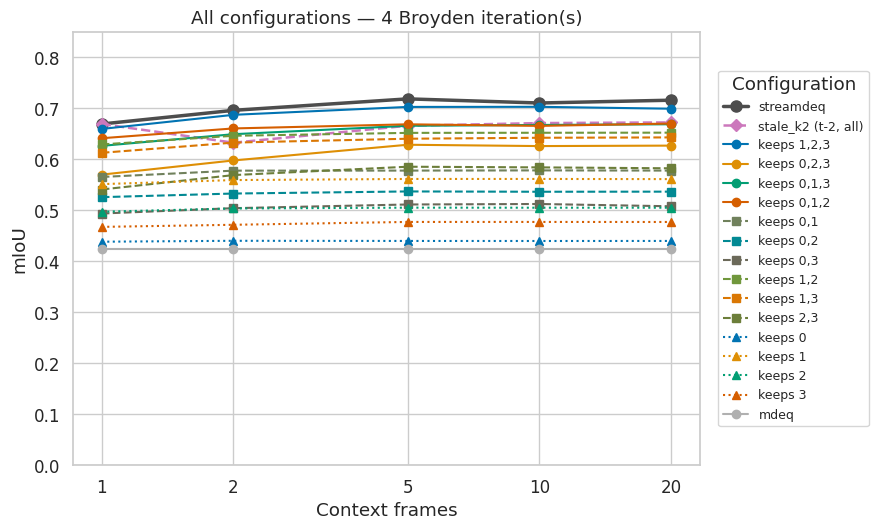

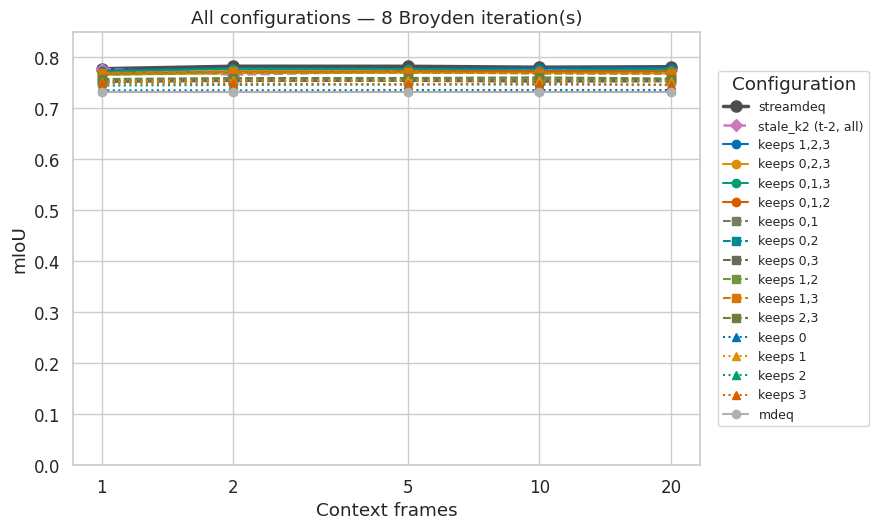

In [6]:
for it in ITER_ORDER:
    data_it = df[df["broyden_iterations"] == it]
    if data_it.empty:
        continue
    fig, ax = plt.subplots(figsize=(9, 5.5))
    plot_configs(ax, data_it, legend_keys)
    ax.set_xscale("log")
    ax.set_xticks([1, 2, 5, 10, 20])
    ax.set_xticklabels(["1", "2", "5", "10", "20"])
    ax.set_xlabel("Context frames")
    ax.set_ylabel("mIoU")
    ax.set_ylim(0, 0.85)
    ax.set_title(f"All configurations — {it} Broyden iteration(s)")
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9, title="Configuration")
    fig.tight_layout()
    plt.show()

At a glance, the 17 configurations spread out between two references: `streamdeq` (all scales warm, on top) and `mdeq` (all scales cold, at the bottom), roughly in order of how many scales they keep warm. The gap between the best and worst configuration is largest at low iteration budgets and shrinks as more Broyden iterations are allowed. Sections 2-9 break this picture down to isolate exactly which scales drive it.

## 2. Baselines: `streamdeq` vs `mdeq` vs `stale_k2`

Before getting into the scale-level detail, this is the Phase 0 reference: how much *any* temporal warm-start (reusing the previous frame or the one from 2 frames ago) matters versus starting from zero. Same per-iteration figure layout as the master curve, but filtered to just these 3 configurations to see them without noise.

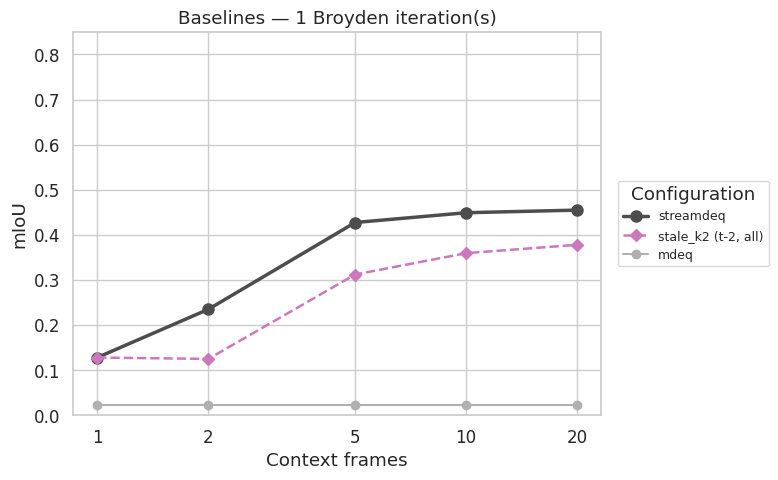

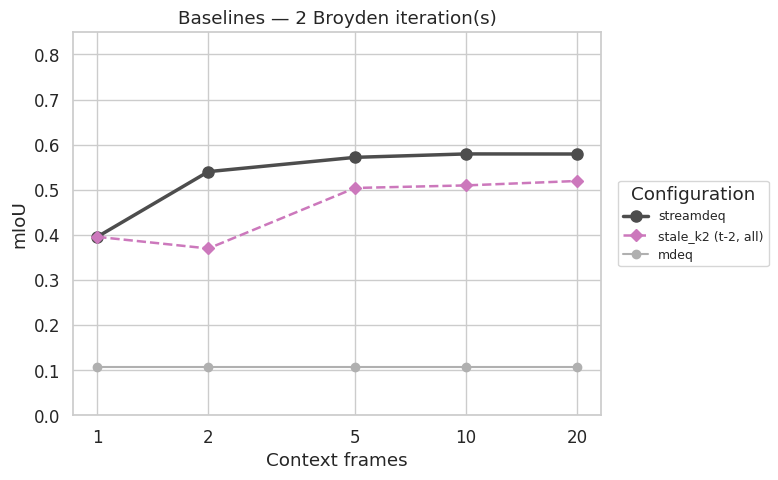

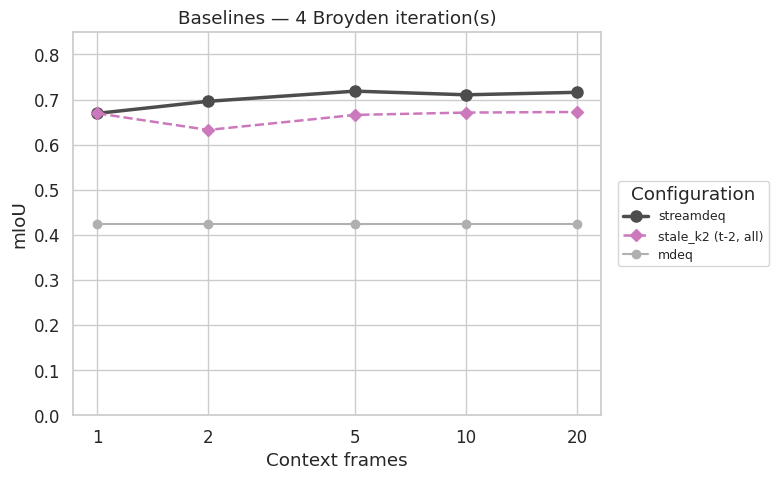

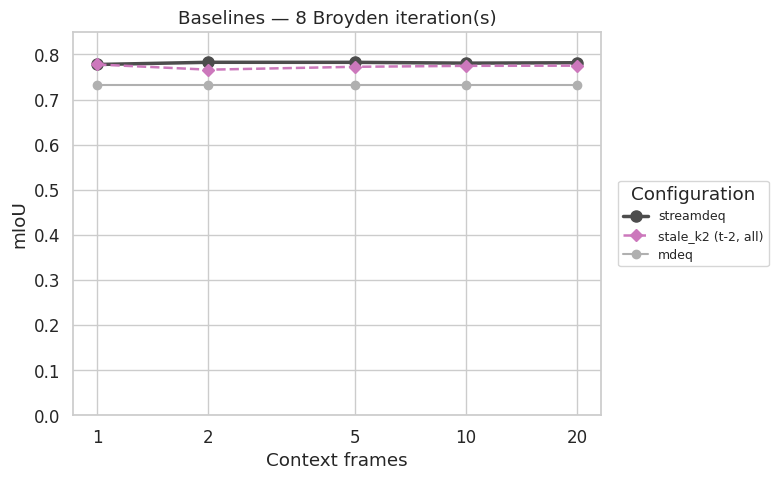

In [20]:
baseline_keys = [
    ("phase0_global", "previous"),
    ("phase0_global", "stale_k2"),
    ("phase0_global", "zero"),
]
baseline_keys = [k for k in baseline_keys if k in CONFIG_META]

for it in ITER_ORDER:
    data_it = df[df["broyden_iterations"] == it]
    if data_it.empty:
        continue
    fig, ax = plt.subplots(figsize=(8, 5))
    plot_configs(ax, data_it, baseline_keys)
    ax.set_xscale("log")
    ax.set_xticks([1, 2, 5, 10, 20])
    ax.set_xticklabels(["1", "2", "5", "10", "20"])
    ax.set_xlabel("Context frames")
    ax.set_ylabel("mIoU")
    ax.set_ylim(0, 0.85)
    ax.set_title(f"Baselines — {it} Broyden iteration(s)")
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9, title="Configuration")
    fig.tight_layout()
    plt.show()

Averaged over every context/iteration combination, `streamdeq` reaches 0.589 mIoU, `stale_k2` 0.539, and `mdeq` (no reuse at all) only 0.321; warm-starting is clearly worth a lot on average. But the *size* of that gap depends heavily on the iteration budget: `streamdeq` beats `mdeq` by 0.317 mIoU at 1 iteration, but by only 0.049 at 8 iterations. In other words, warm-starting matters most when each frame only gets a tiny compute budget; given enough Broyden iterations, the solver can nearly make up for a cold start on its own. `stale_k2` sitting between the two confirms that even a 2-frame-old state is far better than nothing.

## 3. Fraction of the mdeq&rarr;streamdeq gap recovered by each configuration

`R = (mIoU(config) - mIoU(mdeq)) / (mIoU(streamdeq) - mIoU(mdeq))`, computed separately for each context/iteration combination (same idea as Table 27 in the logbook). R=0 is equivalent to `mdeq`, R=1 is equivalent to `streamdeq`. This removes the effect of everything converging to the same mIoU at high iteration counts, and lets the *relative* importance of each scale show through in a way that's comparable across all budgets.

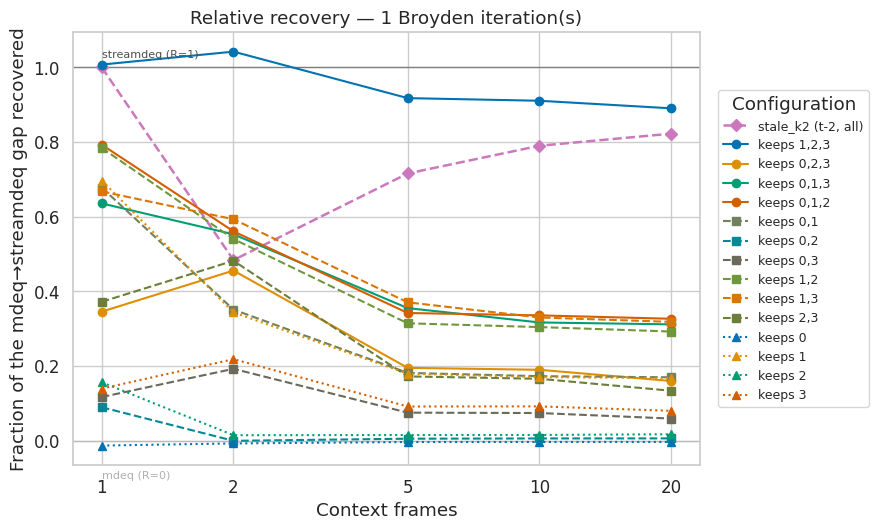

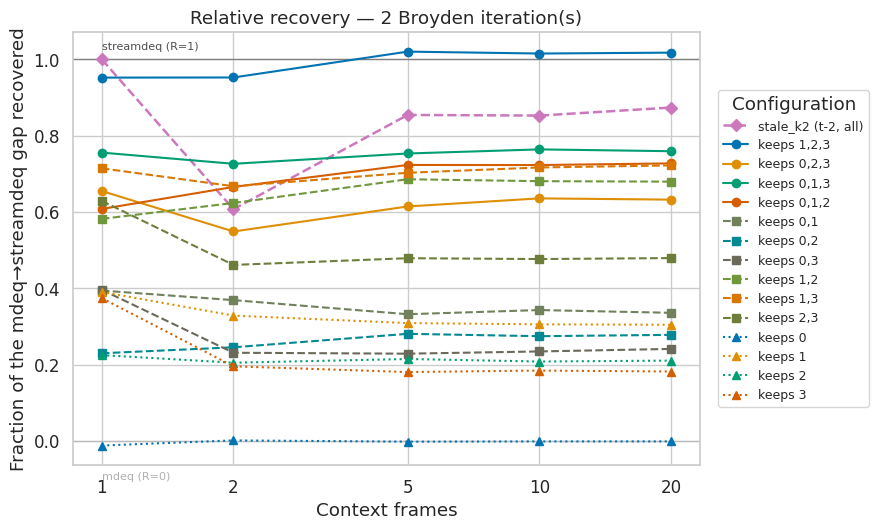

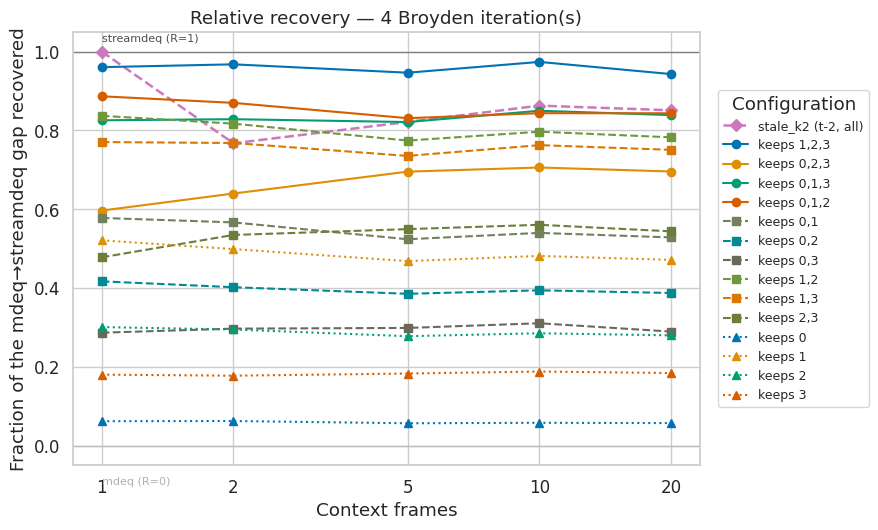

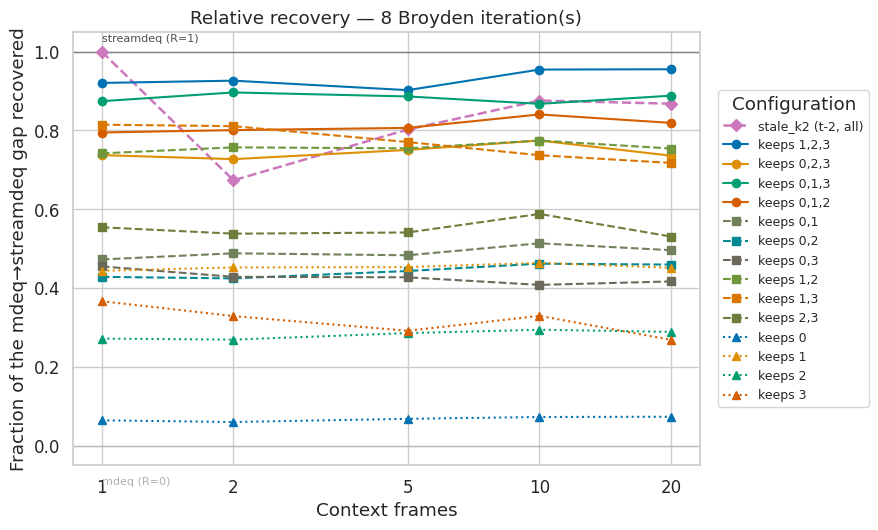

In [26]:
ref = (
    df[(df["phase"] == "phase0_global") & (df["init_name"].isin(["previous", "zero"]))]
    .pivot_table(index=["context", "broyden_iterations"], columns="init_name", values="miou")
    .reset_index()
    .rename(columns={"previous": "miou_previous", "zero": "miou_zero"})
)

df_r = df.merge(ref, on=["context", "broyden_iterations"], how="left")
denom = df_r["miou_previous"] - df_r["miou_zero"]
df_r["recovery"] = (df_r["miou"] - df_r["miou_zero"]) / denom
df_r.loc[denom.abs() < 1e-9, "recovery"] = float("nan")

# previous/zero are trivial here (R=1 and R=0 by definition); shown as
# horizontal reference lines instead of repeating them as series.
recovery_keys = [k for k in legend_keys if k not in [("phase0_global", "previous"), ("phase0_global", "zero")]]

for it in ITER_ORDER:
    data_it = df_r[df_r["broyden_iterations"] == it]
    if data_it.empty:
        continue
    fig, ax = plt.subplots(figsize=(9, 5.5))
    ax.axhline(1.0, color=REFERENCE_COLORS["previous"], linewidth=1, alpha=0.6)
    ax.axhline(0.0, color=REFERENCE_COLORS["zero"], linewidth=1, alpha=0.6)
    ax.text(1, 1.02, "streamdeq (R=1)", fontsize=8, color=REFERENCE_COLORS["previous"], va="bottom")
    ax.text(1, -0.08, "mdeq (R=0)", fontsize=8, color=REFERENCE_COLORS["zero"], va="top")

    for phase, init_name in recovery_keys:
        sub = data_it[(data_it["phase"] == phase) & (data_it["init_name"] == init_name)].sort_values("context_n")
        if sub.empty:
            continue
        label, color, ls, marker, lw, ms = CONFIG_META[(phase, init_name)]
        ax.plot(sub["context_n"], sub["recovery"], color=color, linestyle=ls, marker=marker,
                linewidth=lw, markersize=ms, label=label)

    ax.set_xscale("log")
    ax.set_xticks([1, 2, 5, 10, 20])
    ax.set_xticklabels(["1", "2", "5", "10", "20"])
    ax.set_xlabel("Context frames")
    ax.set_ylabel("Fraction of the mdeq→streamdeq gap recovered")
    ax.set_title(f"Relative recovery — {it} Broyden iteration(s)")
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9, title="Configuration")
    fig.tight_layout()
    plt.show()

Average recovery by group: leave-1-out (3 scales warm) recovers 74% of the gap, leave-2-out (2 warm) 46%, leave-3-out (1 warm) 21%. Losing scales costs more than a simple linear split would suggest: going from 4→3 active scales only gives up ~26 points of recovery, but each scale removed after that costs progressively more. Recovery also improves markedly with more Broyden iterations (53% at 1 iteration → 84% at 8), the same pattern as Section 2: more solver compute compensates for a worse initialization.

## 4. Leave-1-out: turning off a single scale

`previous` (reference, all active) against turning off each scale individually. The scale whose removal hurts the most is the most important for the warm-start.

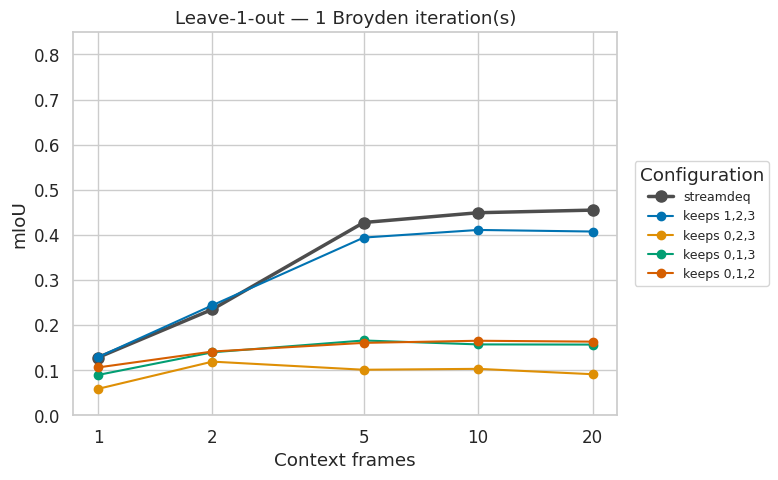

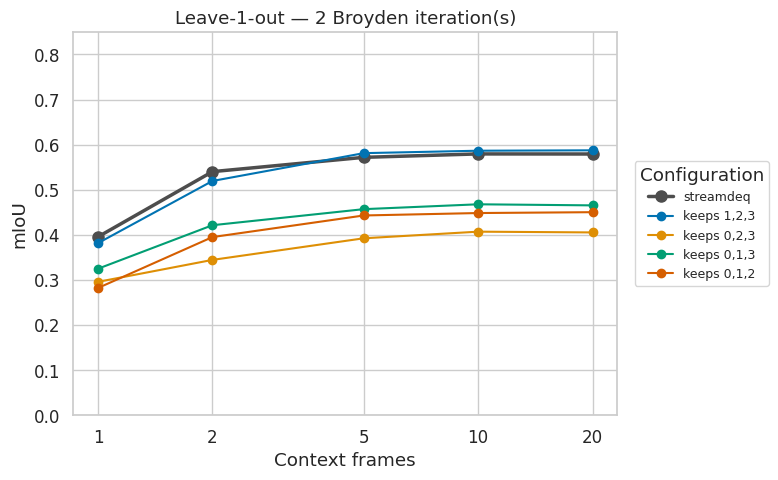

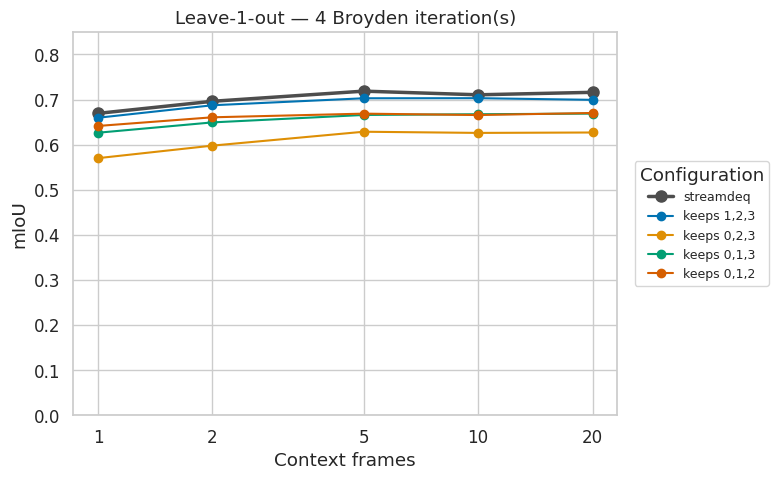

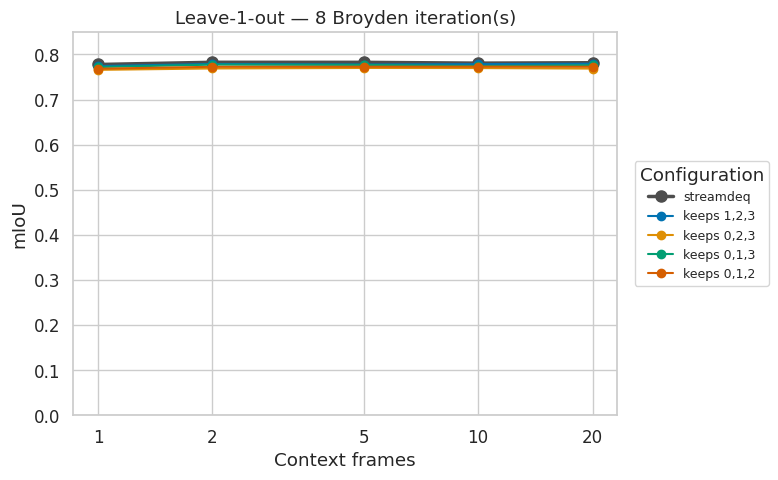

In [9]:
leave1_keys = [("phase0_global", "previous")] + [
    k for k in legend_keys if k[0] == "phase1_leave_one_scale"
]

for it in ITER_ORDER:
    data_it = df[df["broyden_iterations"] == it]
    if data_it.empty:
        continue
    fig, ax = plt.subplots(figsize=(8, 5))
    plot_configs(ax, data_it, leave1_keys)
    ax.set_xscale("log")
    ax.set_xticks([1, 2, 5, 10, 20])
    ax.set_xticklabels(["1", "2", "5", "10", "20"])
    ax.set_xlabel("Context frames")
    ax.set_ylabel("mIoU")
    ax.set_ylim(0, 0.85)
    ax.set_title(f"Leave-1-out — {it} Broyden iteration(s)")
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9, title="Configuration")
    fig.tight_layout()
    plt.show()

Average mIoU when each single scale is the one reset (lower = that scale matters more): resetting scale 1 hurts the most (0.461), then scale 3 (0.496) and scale 2 (0.500, essentially tied with scale 3), and resetting scale 0 barely matters at all (0.579, almost identical to keeping all 4 warm, at 0.589). This is the clearest single piece of evidence in the whole sweep that **scale 1 is the one worth warm-starting if you can only pick one to protect**, and that scale 0 is the one you can most safely reset every frame.

## 5. Leave-2-out: keeping only 2 scales active

`previous` (reference) against the 6 possible combinations of two active scales (the other 2 are turned off). Combinations that include scale 1 should end up above those that don't.

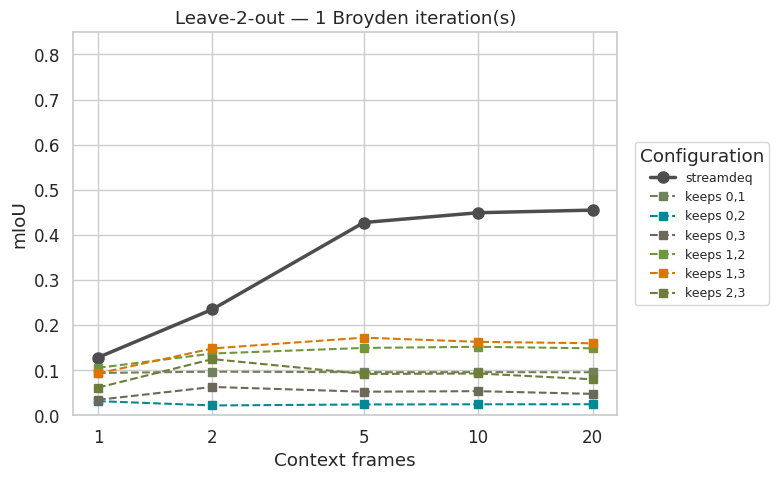

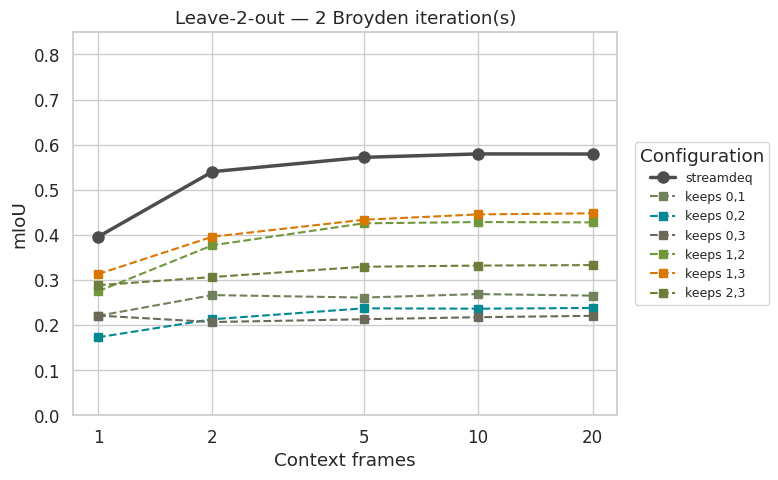

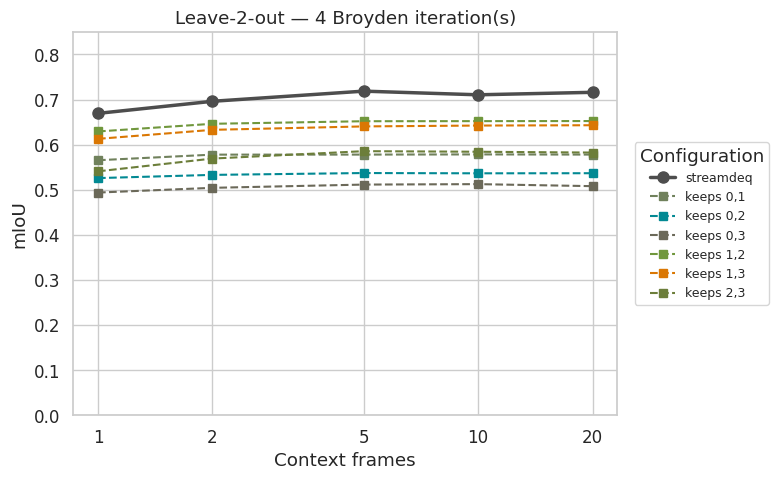

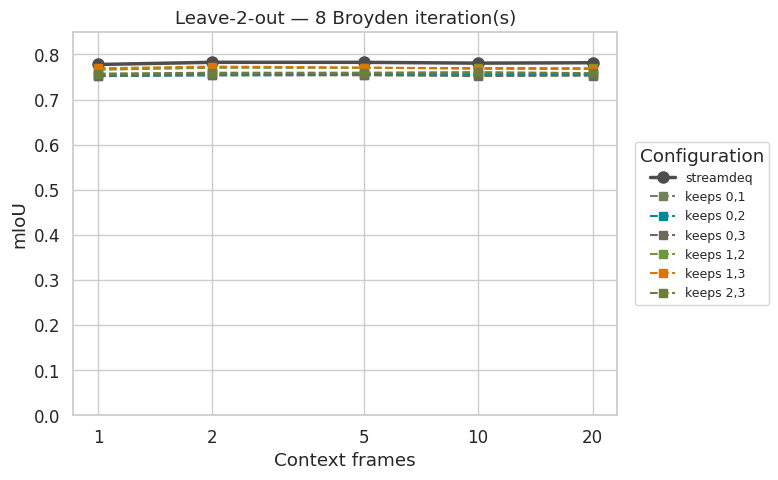

In [10]:
leave2_keys = [("phase0_global", "previous")] + [
    k for k in legend_keys if k[0] == "phase1_two_scale"
]

for it in ITER_ORDER:
    data_it = df[df["broyden_iterations"] == it]
    if data_it.empty:
        continue
    fig, ax = plt.subplots(figsize=(8, 5))
    plot_configs(ax, data_it, leave2_keys)
    ax.set_xscale("log")
    ax.set_xticks([1, 2, 5, 10, 20])
    ax.set_xticklabels(["1", "2", "5", "10", "20"])
    ax.set_xlabel("Context frames")
    ax.set_ylabel("mIoU")
    ax.set_ylim(0, 0.85)
    ax.set_title(f"Leave-2-out — {it} Broyden iteration(s)")
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9, title="Configuration")
    fig.tight_layout()
    plt.show()

Ranked by average mIoU, `keeps 1,3` (0.490) and `keeps 1,2` (0.485) are the two best pairs; `keeps 0,2` (0.383) and `keeps 0,3` (0.381) are the two worst. Every pair that includes scale 1 clearly separates from every pair that doesn't: scale 1 is the common ingredient in all of the strong combinations, consistent with Section 4.

## 6. Leave-3-out: keeping only a single scale active

`previous` (reference) against keeping only one scale (the other 3 are turned off). This is the most extreme case of partial initialization.

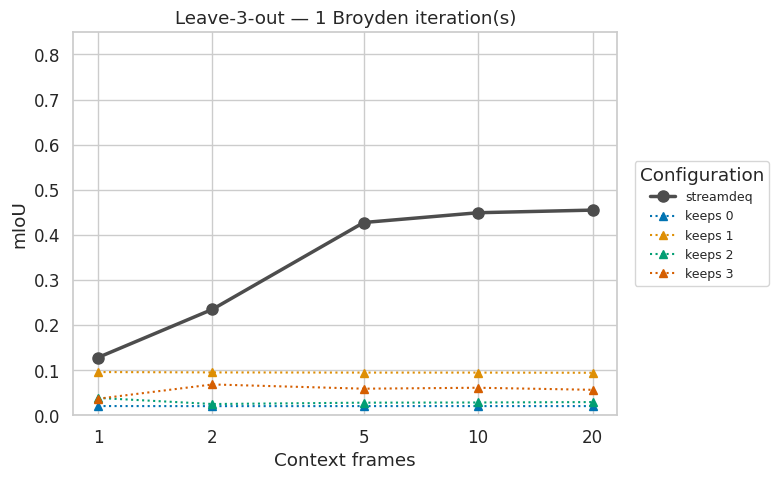

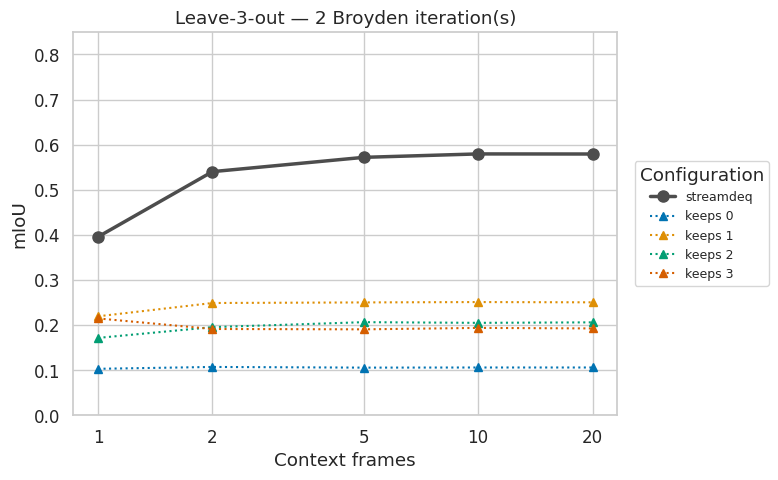

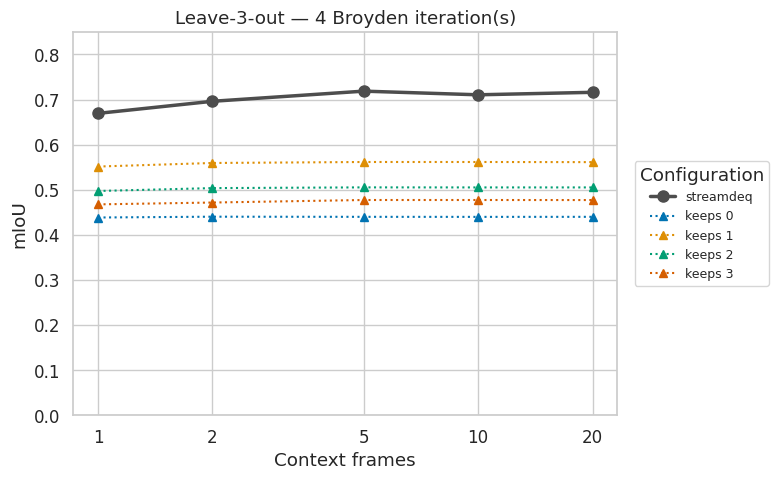

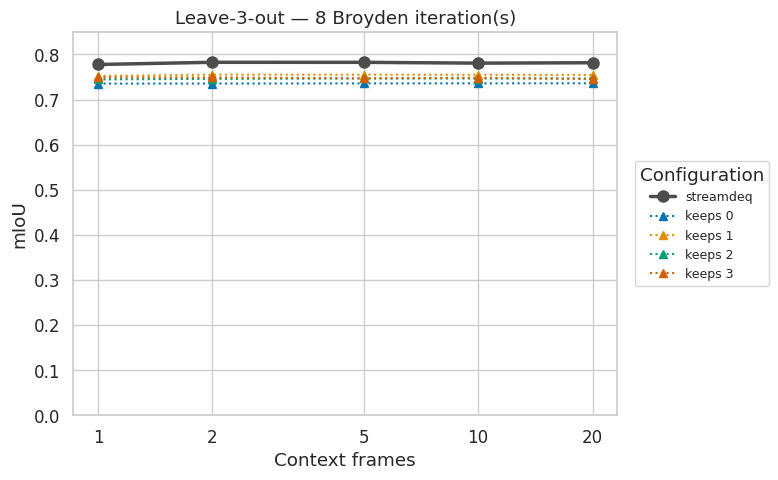

In [11]:
leave3_keys = [("phase0_global", "previous")] + [
    k for k in legend_keys if k[0] == "phase1_three_scale"
]

for it in ITER_ORDER:
    data_it = df[df["broyden_iterations"] == it]
    if data_it.empty:
        continue
    fig, ax = plt.subplots(figsize=(8, 5))
    plot_configs(ax, data_it, leave3_keys)
    ax.set_xscale("log")
    ax.set_xticks([1, 2, 5, 10, 20])
    ax.set_xticklabels(["1", "2", "5", "10", "20"])
    ax.set_xlabel("Context frames")
    ax.set_ylabel("mIoU")
    ax.set_ylim(0, 0.85)
    ax.set_title(f"Leave-3-out — {it} Broyden iteration(s)")
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9, title="Configuration")
    fig.tight_layout()
    plt.show()

Even in the most extreme case (only one scale warm, the other three reset every frame) keeping only scale 1 (0.413 mIoU) beats keeping only scale 2 (0.369) or only scale 3 (0.369, tied), and keeping only scale 0 alone is the worst option (0.325). Scale 1 comes out on top in every leave-N-out comparison so far (Sections 4, 5 and 6), regardless of how many other scales are active alongside it.

## 7. Summary: mIoU by how many scales are kept active

One line per "how many scales active" (0 in `zero`, 4 in `previous`/`stale_k2`), averaging the specific variants in each group (e.g. leave-2-out averages the 6 pair combinations) with a min-max band so the variation within each group isn't lost. Color follows an ordered `viridis` gradient (darker/cooler = fewer active scales, brighter/warmer = more) since this is a magnitude variable, not an identity one.

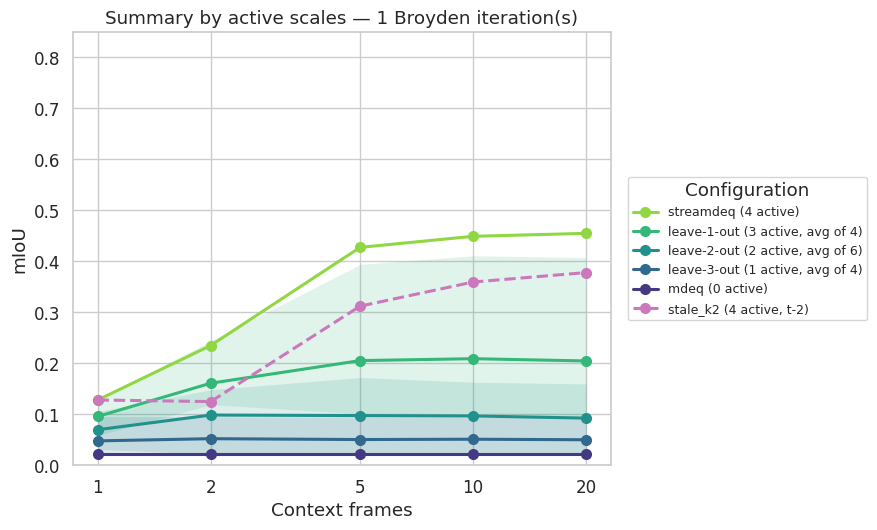

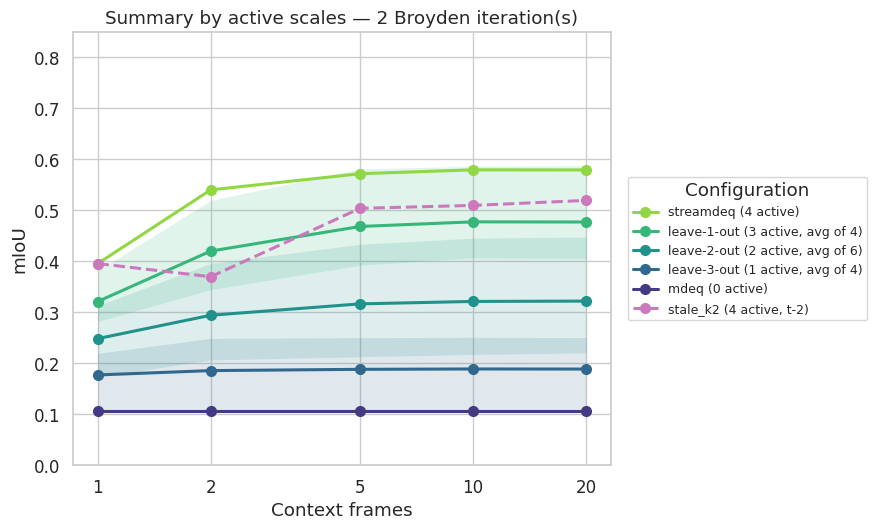

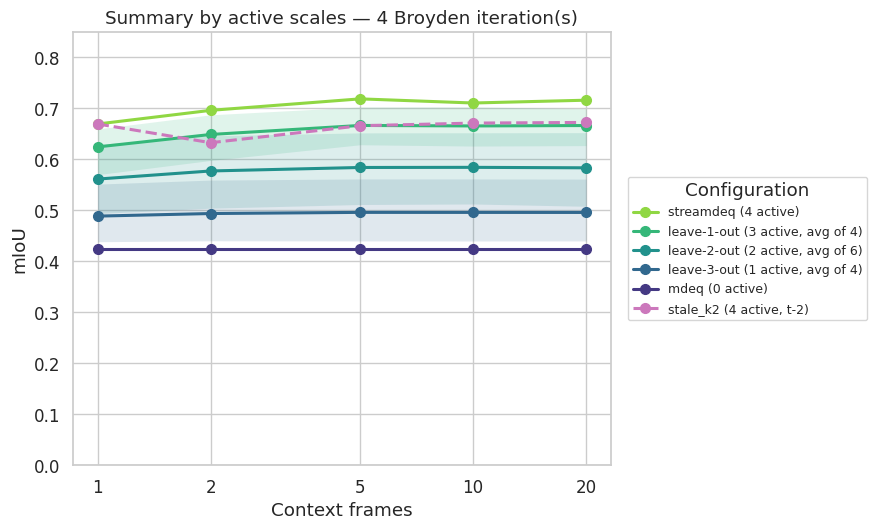

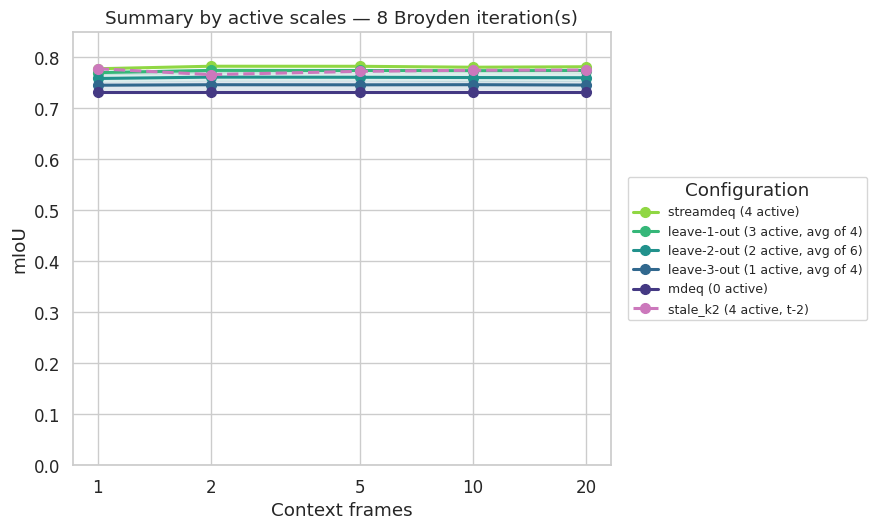

In [14]:
PHASE_TO_FAMILY = {
    "phase1_leave_one_scale": "leave_one_out",
    "phase1_two_scale": "leave_two_out",
    "phase1_three_scale": "leave_three_out",
}

def to_family(row):
    if row["phase"] == "phase0_global":
        return row["init_name"]
    return PHASE_TO_FAMILY[row["phase"]]

df["family"] = df.apply(to_family, axis=1)

FAMILY_ORDER = ["previous", "leave_one_out", "leave_two_out", "leave_three_out", "zero", "stale_k2"]
FAMILY_LABELS = {
    "previous": "streamdeq (4 active)",
    "leave_one_out": "leave-1-out (3 active, avg of 4)",
    "leave_two_out": "leave-2-out (2 active, avg of 6)",
    "leave_three_out": "leave-3-out (1 active, avg of 4)",
    "zero": "mdeq (0 active)",
    "stale_k2": "stale_k2 (4 active, t-2)",
}
# Previously this was a grayscale ramp (same hue, only brightness changed) and
# the lines were hard to tell apart. Now it uses viridis, which is still an
# ordered gradient (same direction: more active scales = more toward yellow)
# but with enough hue change between steps to be visible at a glance.
_viridis = sns.color_palette("viridis", n_colors=5)
FAMILY_COLORS = {
    "previous": _viridis[4],
    "leave_one_out": _viridis[3],
    "leave_two_out": _viridis[2],
    "leave_three_out": _viridis[1],
    "zero": _viridis[0],
    "stale_k2": _colorblind[4],
}

family_agg = (
    df[df["family"].isin(FAMILY_ORDER)]
    .groupby(["context", "context_n", "broyden_iterations", "family"], as_index=False)["miou"]
    .agg(mean="mean", min="min", max="max")
)

for it in ITER_ORDER:
    data_it = family_agg[family_agg["broyden_iterations"] == it]
    if data_it.empty:
        continue
    fig, ax = plt.subplots(figsize=(9, 5.5))
    for fam in FAMILY_ORDER:
        sub = data_it[data_it["family"] == fam].sort_values("context_n")
        if sub.empty:
            continue
        color = FAMILY_COLORS[fam]
        ls = "--" if fam == "stale_k2" else "-"
        ax.plot(sub["context_n"], sub["mean"], color=color, linestyle=ls, marker="o",
                linewidth=2.2, markersize=7, label=FAMILY_LABELS[fam])
        if (sub["max"] - sub["min"]).max() > 1e-9:
            ax.fill_between(sub["context_n"], sub["min"], sub["max"], color=color, alpha=0.15, linewidth=0)
    ax.set_xscale("log")
    ax.set_xticks([1, 2, 5, 10, 20])
    ax.set_xticklabels(["1", "2", "5", "10", "20"])
    ax.set_xlabel("Context frames")
    ax.set_ylabel("mIoU")
    ax.set_ylim(0, 0.85)
    ax.set_title(f"Summary by active scales — {it} Broyden iteration(s)")
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9, title="Configuration")
    fig.tight_layout()
    plt.show()

Average mIoU forms a clean staircase as scales are removed: `streamdeq` (0.589, 4 active) > `stale_k2` (0.539, 4 active but 2 frames old) > leave-1-out (0.509, 3 active) > leave-2-out (0.432, 2 active) > leave-3-out (0.369, 1 active) > `mdeq` (0.321, 0 active). One detail worth noting: `stale_k2` (all 4 scales, just outdated) beats leave-1-out (3 fresh scales, one reset): a slightly stale *complete* state can still outperform a fresh but *incomplete* one, suggesting that having all 4 scales fuse together every iteration matters even when the values being fused aren't perfectly current.

## 8. Best pair vs worst pair of scales

The two best two-scale combinations (`keeps 1,3` and `keeps 1,2`, both include scale 1) against the two worst (`keeps 0,2` and `keeps 0,3`, neither includes scale 1). This is the most direct proof that scale 1 contributes the most.

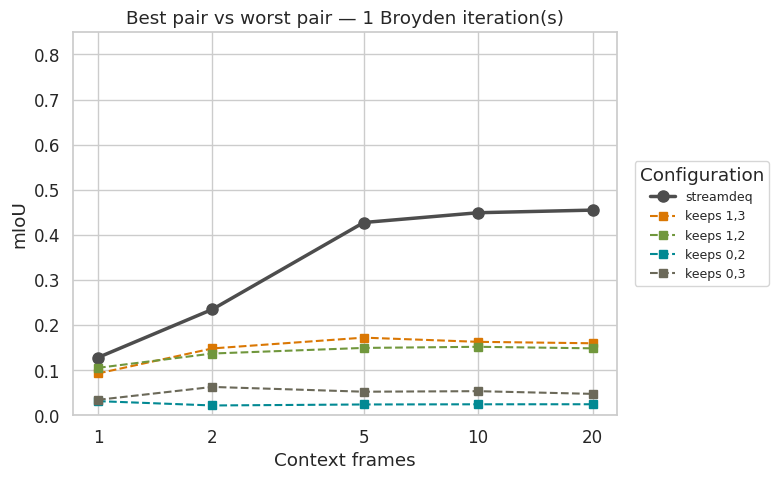

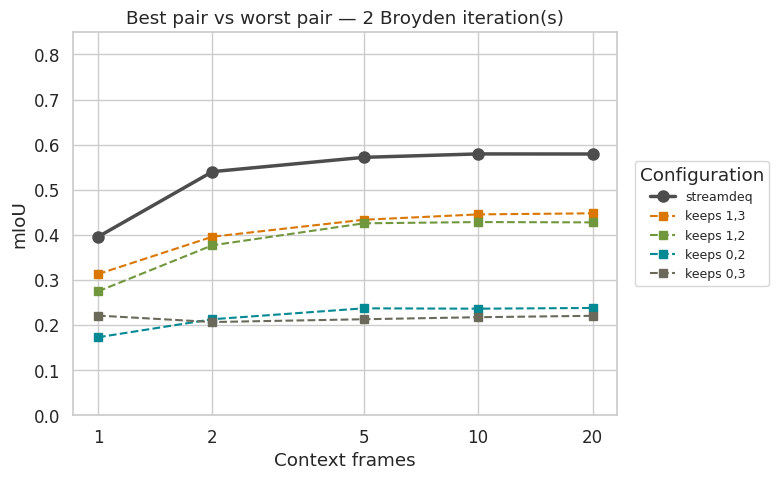

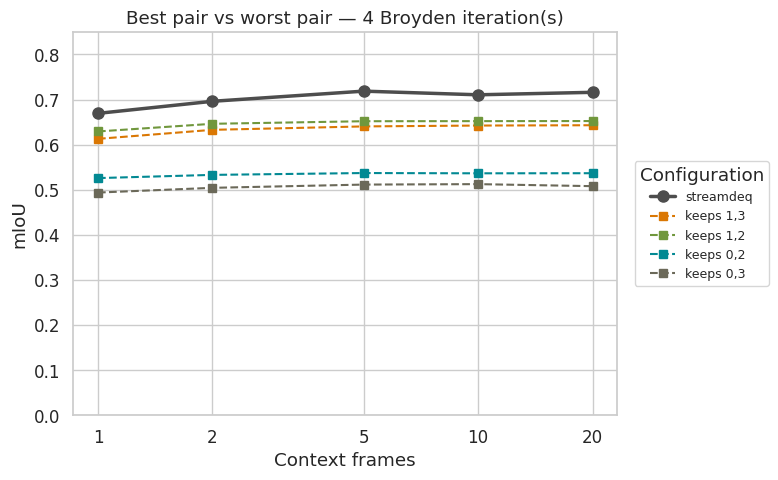

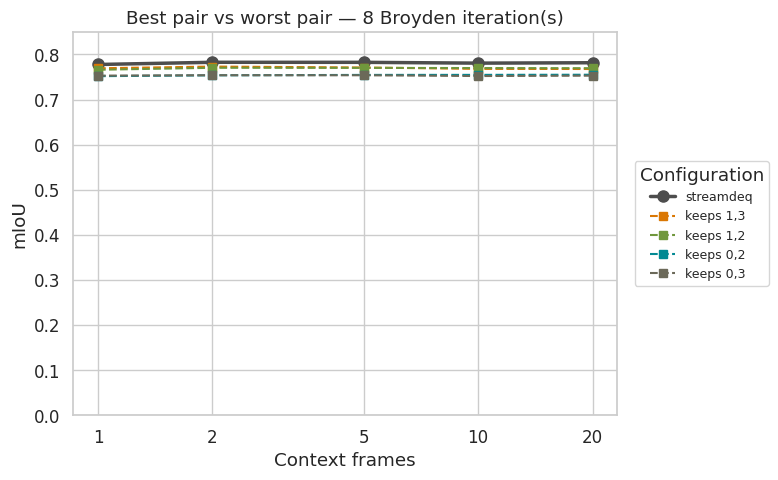

In [15]:
best_worst_keys = [
    ("phase0_global", "previous"),
    ("phase1_two_scale", "scale1_scale3_previous"),
    ("phase1_two_scale", "scale1_scale2_previous"),
    ("phase1_two_scale", "scale0_scale2_previous"),
    ("phase1_two_scale", "scale0_scale3_previous"),
]
best_worst_keys = [k for k in best_worst_keys if k in CONFIG_META]

for it in ITER_ORDER:
    data_it = df[df["broyden_iterations"] == it]
    if data_it.empty:
        continue
    fig, ax = plt.subplots(figsize=(8, 5))
    plot_configs(ax, data_it, best_worst_keys)
    ax.set_xscale("log")
    ax.set_xticks([1, 2, 5, 10, 20])
    ax.set_xticklabels(["1", "2", "5", "10", "20"])
    ax.set_xlabel("Context frames")
    ax.set_ylabel("mIoU")
    ax.set_ylim(0, 0.85)
    ax.set_title(f"Best pair vs worst pair — {it} Broyden iteration(s)")
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9, title="Configuration")
    fig.tight_layout()
    plt.show()

The two curves that include scale 1 (`keeps 1,3` and `keeps 1,2`) sit clearly above the two that don't (`keeps 0,2` and `keeps 0,3`) at every context length and every iteration budget; the separation is consistent, not a coincidence of one particular setting. This is the most direct visual confirmation that scale 1 is what distinguishes a good pair from a bad one.

## 9. Marginal importance of each scale (all compared in a single chart)

For each scale K, **all** configurations are grouped into two buckets: those that keep K warm-started (includes `streamdeq`, `stale_k2`, the leave-1-out runs that don't reset K, the pairs that include K, and `keeps K` from leave-3-out) and those that reset it (`mdeq`, the leave-1-out run that resets K, the pairs that don't include it, and the `keeps J` runs with J≠K). The importance of scale K is the difference between the average recovery (see section 3) of the "K warm" group and the "K reset" group, computed separately for each context and iteration count.

This directly answers "how important is scale 1 across all configurations" (and the same for 0, 2, and 3) in a single curve per scale, averaging over whatever else happens to be on or off at the same time.

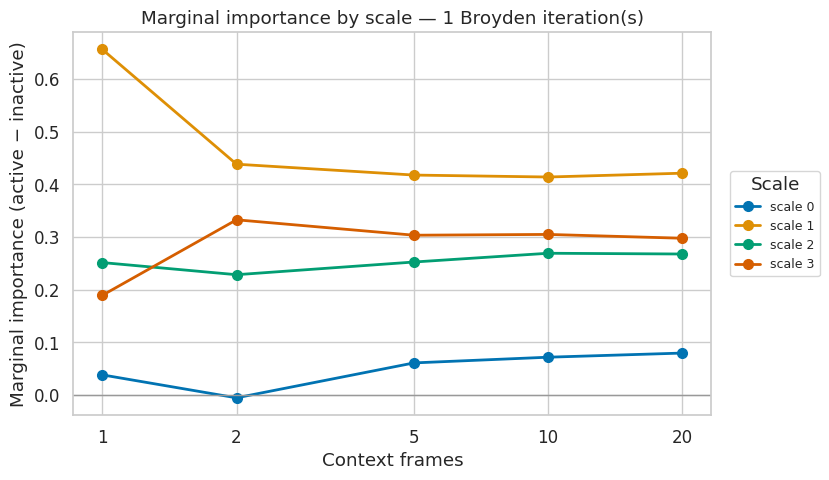

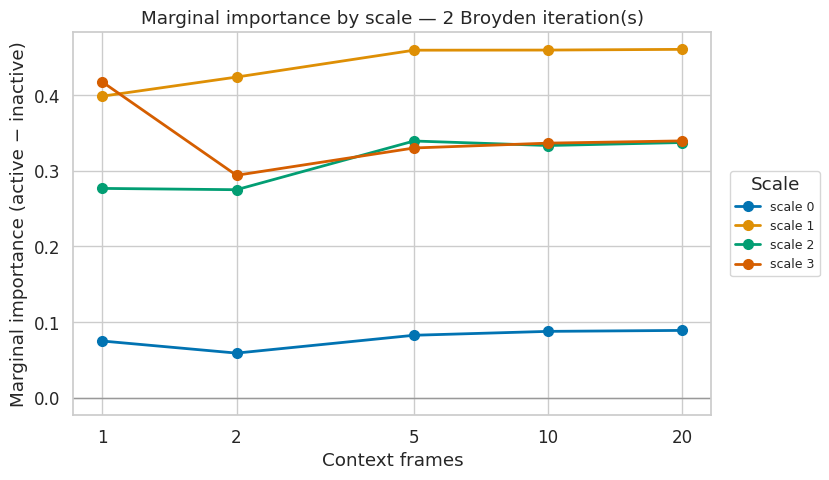

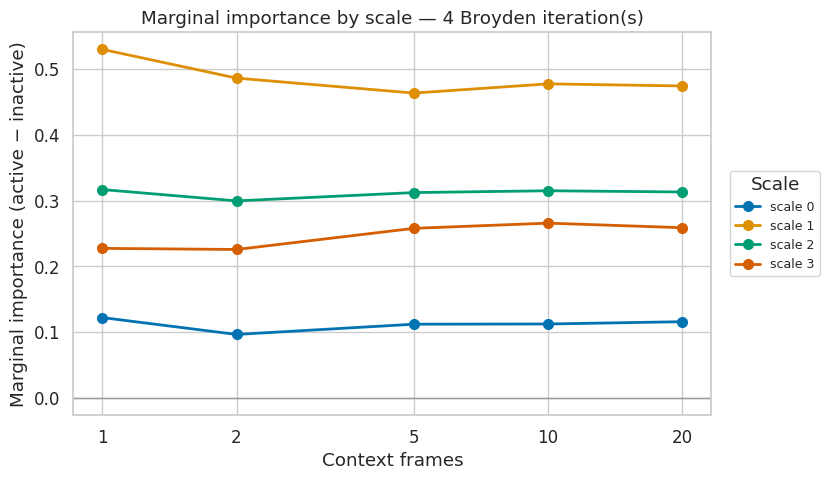

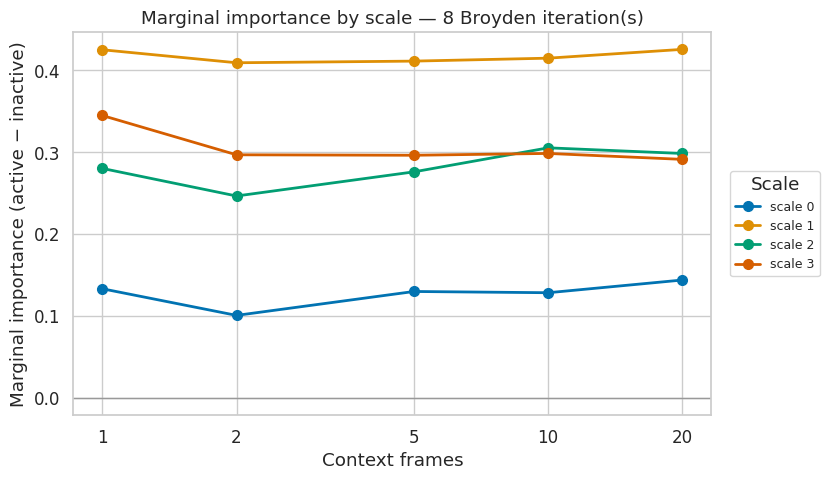

In [16]:
def active_scales(phase, init_name):
    if phase == "phase0_global":
        if init_name in ("previous", "stale_k2"):
            return frozenset({0, 1, 2, 3})
        if init_name == "zero":
            return frozenset()
    if phase == "phase1_leave_one_scale":
        k = int(re.search(r"drop_scale(\d)", init_name).group(1))
        return frozenset({0, 1, 2, 3}) - {k}
    if phase == "phase1_two_scale":
        i, j = map(int, re.search(r"scale(\d)_scale(\d)_previous", init_name).groups())
        return frozenset({i, j})
    if phase == "phase1_three_scale":
        k = int(re.search(r"only_scale(\d)_previous", init_name).group(1))
        return frozenset({k})
    raise ValueError((phase, init_name))

df_r["active_scales"] = df_r.apply(lambda r: active_scales(r["phase"], r["init_name"]), axis=1)

importance_rows = []
for k in range(4):
    is_active = df_r["active_scales"].apply(lambda s: k in s)
    active_avg = df_r[is_active].groupby(["context_n", "broyden_iterations"])["recovery"].mean().rename("active")
    inactive_avg = df_r[~is_active].groupby(["context_n", "broyden_iterations"])["recovery"].mean().rename("inactive")
    merged = pd.concat([active_avg, inactive_avg], axis=1).reset_index()
    merged["scale"] = k
    merged["importance"] = merged["active"] - merged["inactive"]
    importance_rows.append(merged)
importance_df = pd.concat(importance_rows, ignore_index=True)

for it in ITER_ORDER:
    data_it = importance_df[importance_df["broyden_iterations"] == it]
    if data_it.empty:
        continue
    fig, ax = plt.subplots(figsize=(8.5, 5))
    for k in range(4):
        sub = data_it[data_it["scale"] == k].sort_values("context_n")
        if sub.empty:
            continue
        ax.plot(sub["context_n"], sub["importance"], color=SCALE_COLORS[k], marker="o",
                linewidth=2, markersize=7, label=f"scale {k}")
    ax.axhline(0, color="#999999", linewidth=1)
    ax.set_xscale("log")
    ax.set_xticks([1, 2, 5, 10, 20])
    ax.set_xticklabels(["1", "2", "5", "10", "20"])
    ax.set_xlabel("Context frames")
    ax.set_ylabel("Marginal importance (active − inactive)")
    ax.set_title(f"Marginal importance by scale — {it} Broyden iteration(s)")
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9, title="Scale")
    fig.tight_layout()
    plt.show()

Overall marginal importance: scale 1: **0.453**, scale 3: 0.295, scale 2: 0.290, scale 0: **0.092**. Scale 1 is worth about **5x** as much as scale 0, and roughly 1.5x as much as scales 2 or 3 (which are essentially tied with each other). This ranking holds at every iteration budget individually (scale 1 is the highest bar at 1, 2, 4 and 8 iterations alike); it isn't an artifact of averaging. Scale 0's importance does triple from 0.049 (1 iteration) to 0.127 (8 iterations), but never gets close to scale 1's.

## 10. All configurations: mIoU vs Broyden iterations, one figure per context

This is the transpose of section 1: there the x axis was context frames and each figure was one iteration budget; here the x axis is Broyden iterations and each figure is one fixed context length (`1f`, `2f`, `5f`, `10f`, `20f`). Same 17 configurations, same colors/line styles as everywhere else in this notebook.

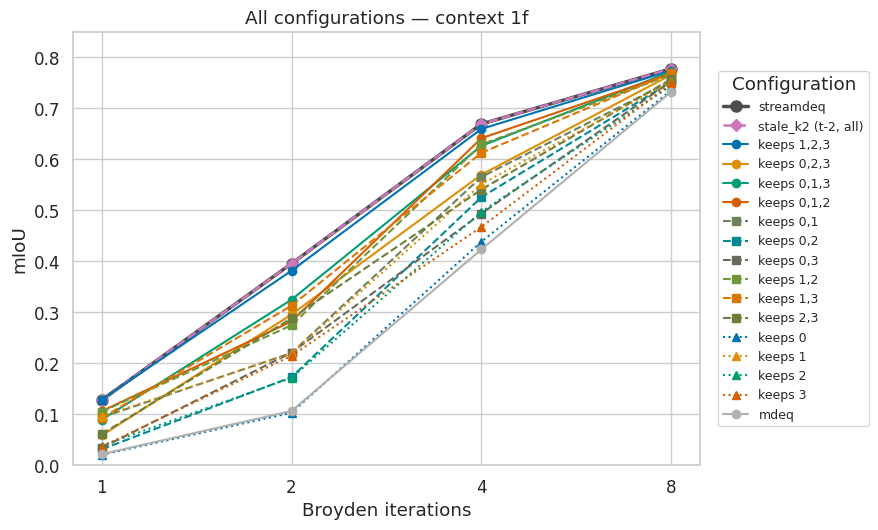

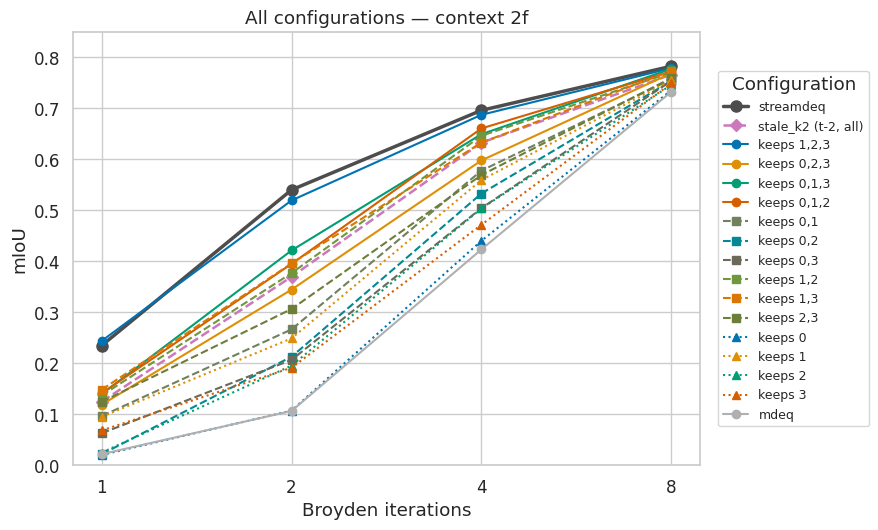

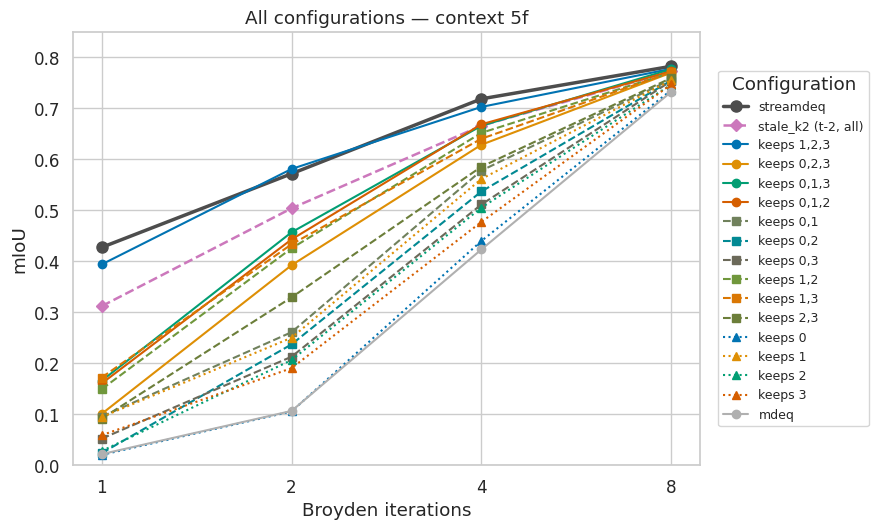

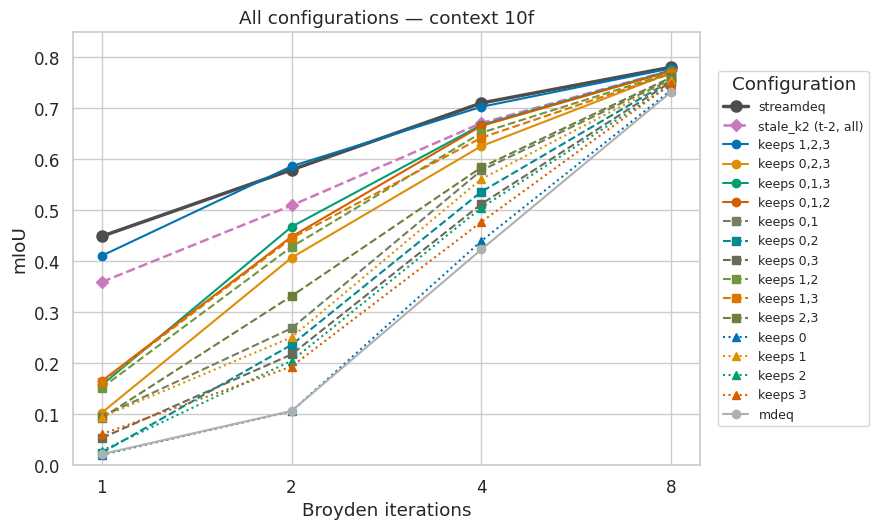

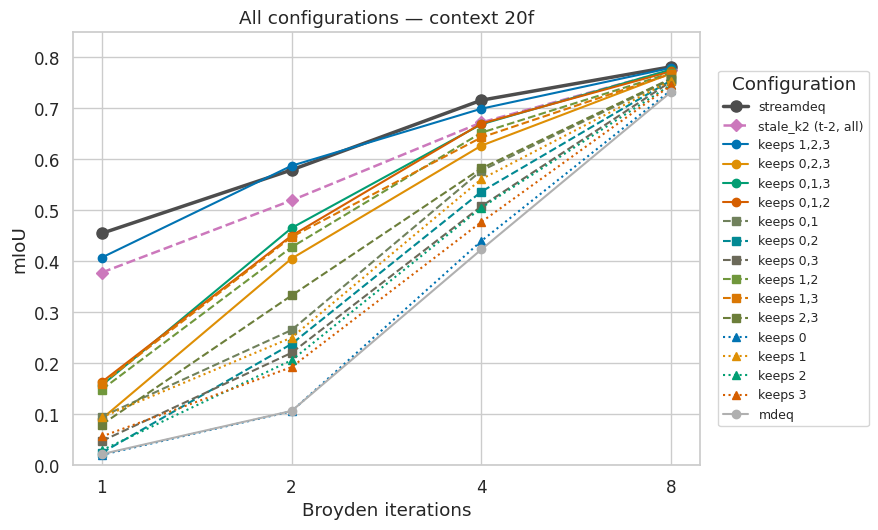

In [15]:
def plot_configs_vs_iters(ax, data, keys):
    for phase, init_name in keys:
        sub = data[(data["phase"] == phase) & (data["init_name"] == init_name)].sort_values("broyden_iterations")
        if sub.empty:
            continue
        label, color, ls, marker, lw, ms = CONFIG_META[(phase, init_name)]
        ax.plot(sub["broyden_iterations"], sub["miou"], color=color, linestyle=ls, marker=marker,
                linewidth=lw, markersize=ms, label=label)

for ctx in CONTEXT_ORDER:
    data_ctx = df[df["context"] == ctx]
    if data_ctx.empty:
        continue
    fig, ax = plt.subplots(figsize=(9, 5.5))
    plot_configs_vs_iters(ax, data_ctx, legend_keys)
    ax.set_xscale("log")
    ax.set_xticks(ITER_ORDER)
    ax.set_xticklabels([str(i) for i in ITER_ORDER])
    ax.minorticks_off()
    ax.set_xlabel("Broyden iterations")
    ax.set_ylabel("mIoU")
    ax.set_ylim(0, 0.85)
    ax.set_title(f"All configurations — context {ctx}")
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9, title="Configuration")
    fig.tight_layout()
    plt.show()

For `streamdeq`, context length matters a lot at low iteration budgets but barely at all at high ones. At 1 Broyden iteration, mIoU goes from 0.128 (context `1f`) to 0.455 (context `20f`), a huge swing, since with only 1 iteration the model leans almost entirely on however warm the state already is. At 8 iterations, the same comparison is 0.778 vs. 0.782, essentially flat. This mirrors Sections 2 and 3 exactly: **more Broyden iterations can substitute for both a better initialization and a longer priming context**, all three point to the same underlying mechanism, the solver needing "help" from somewhere (a warm start, more context, or more compute) to reach a good equilibrium, and any one of them can partly cover for the others.

## 11. Per-configuration: mIoU vs Broyden iterations, one figure per configuration

One more transpose: now each of the 17 configurations gets its own figure, x axis is Broyden iterations, and each line is a context length (`1f`...`20f`). This isolates a single configuration (e.g. `keeps 0,2,3`, meaning scale 1 is reset every frame) and shows whether more context frames change its story. Context length is a magnitude variable (more priming frames), so it gets a sequential color ramp (`mako`, light to dark = fewer to more frames) rather than an arbitrary categorical palette — reused consistently across every figure in this section.

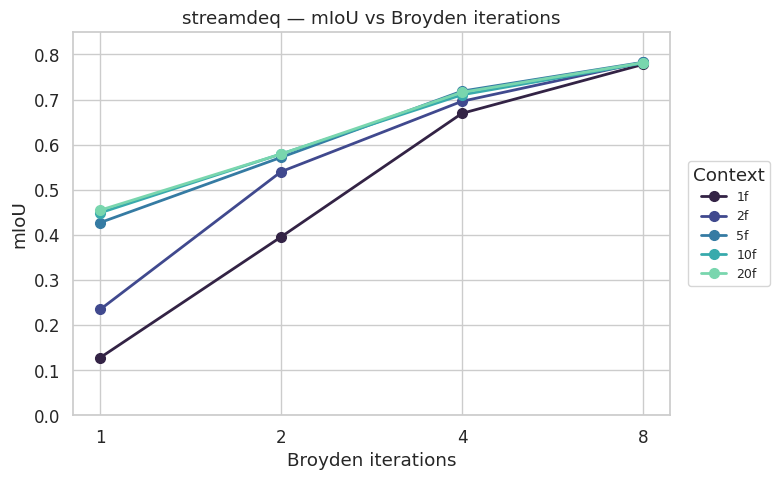

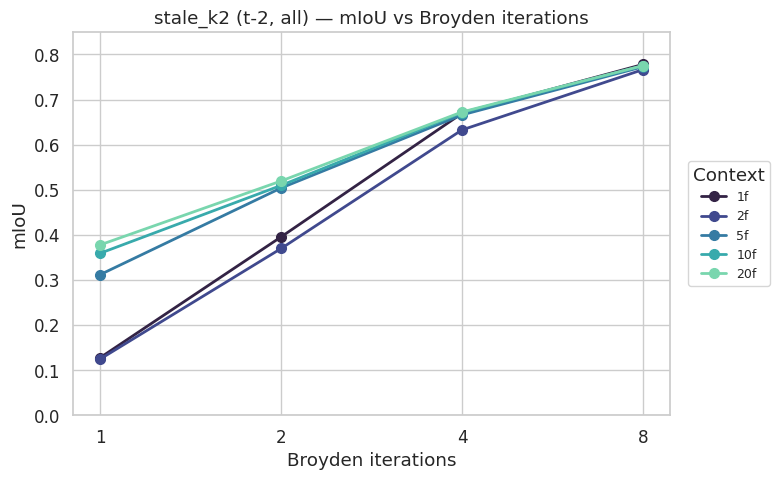

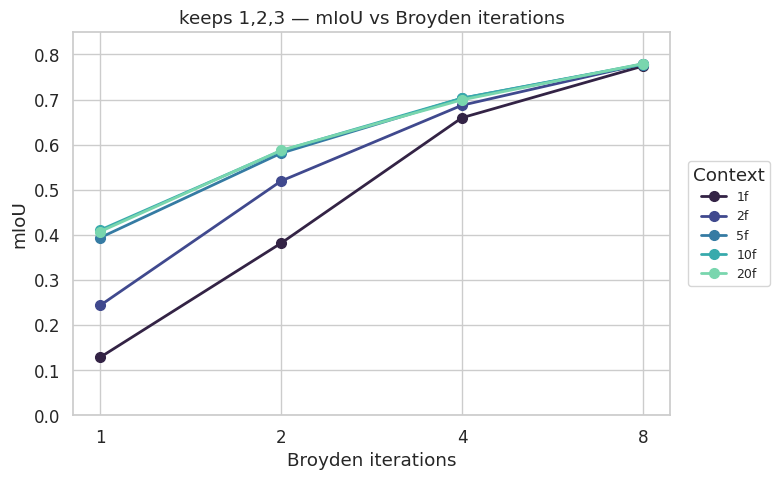

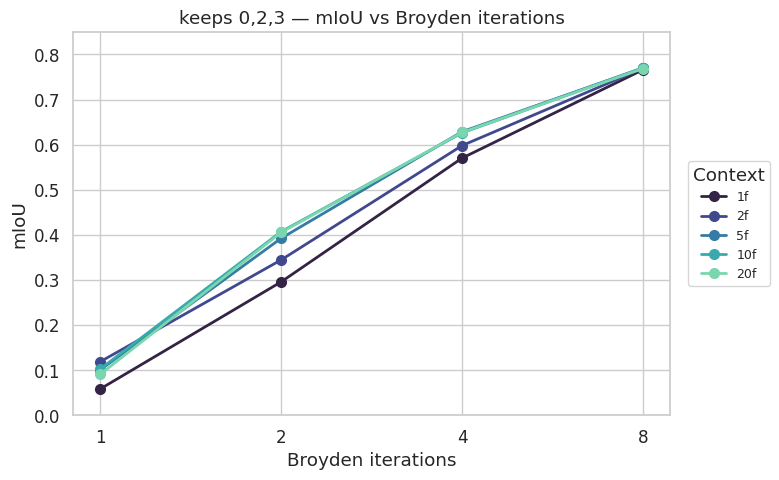

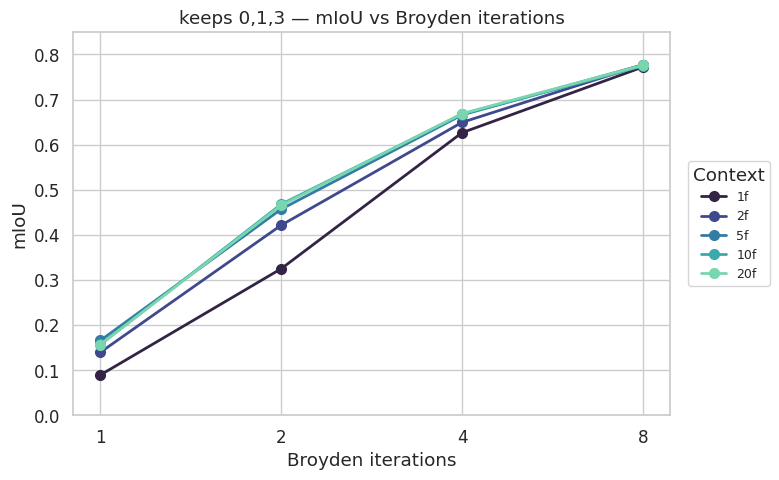

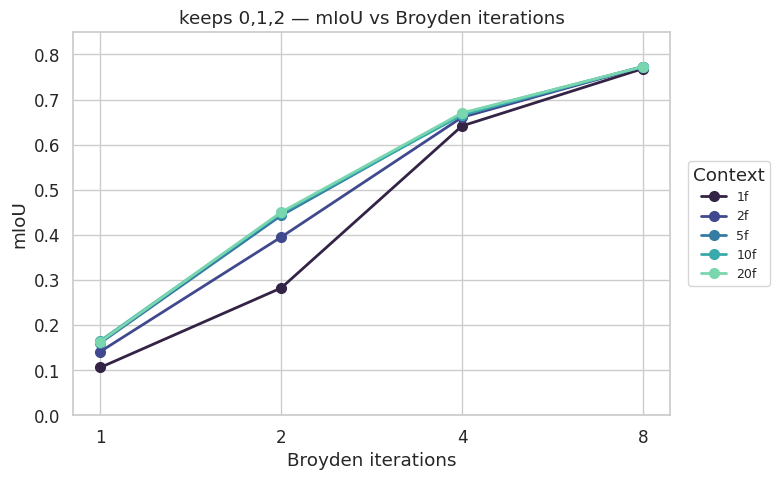

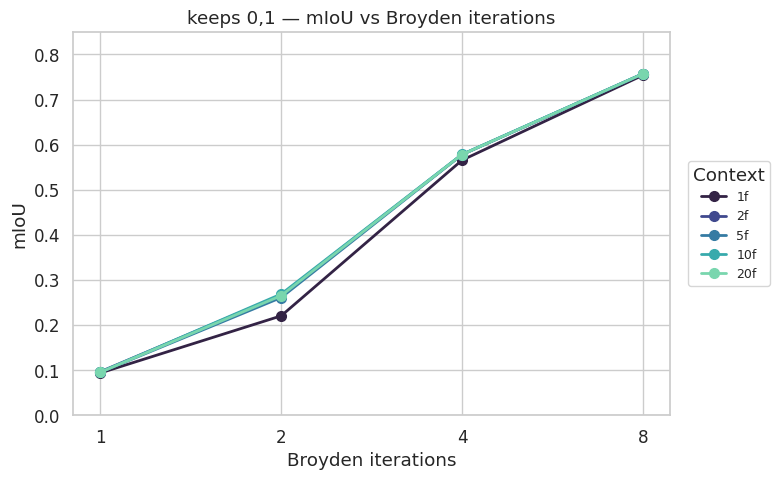

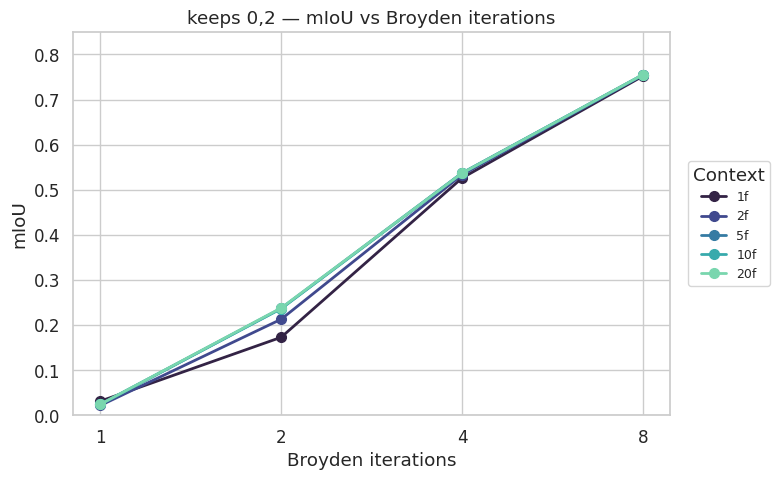

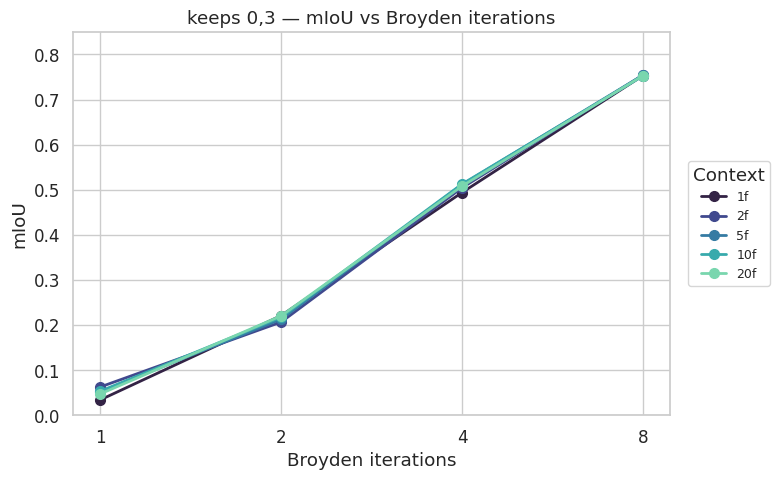

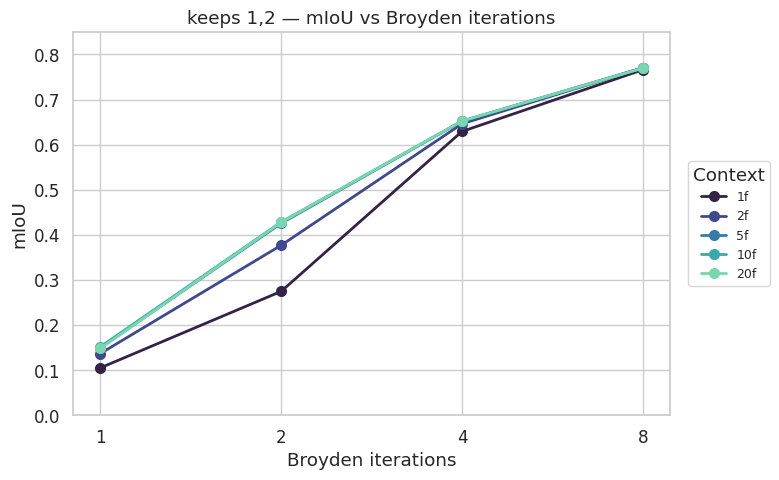

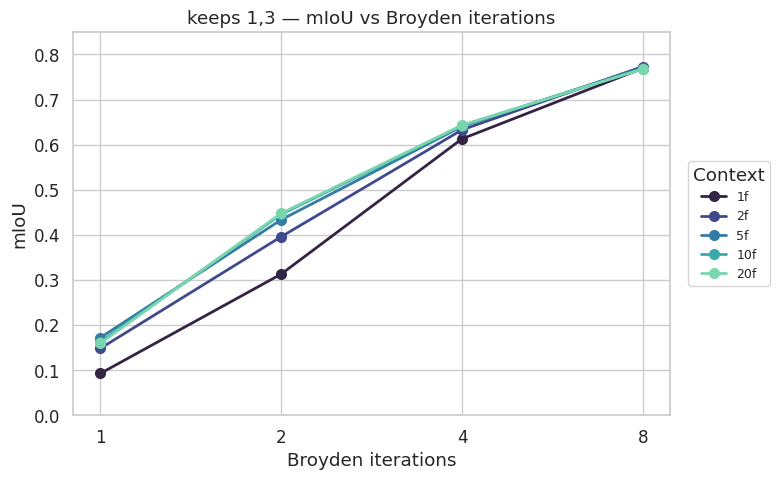

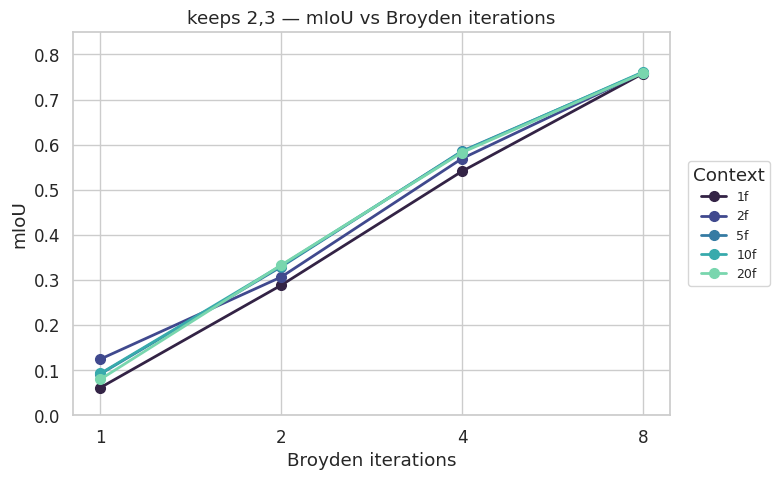

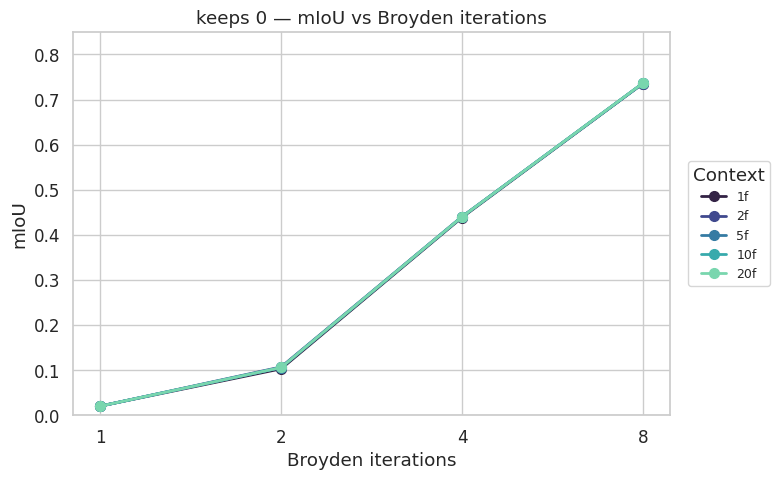

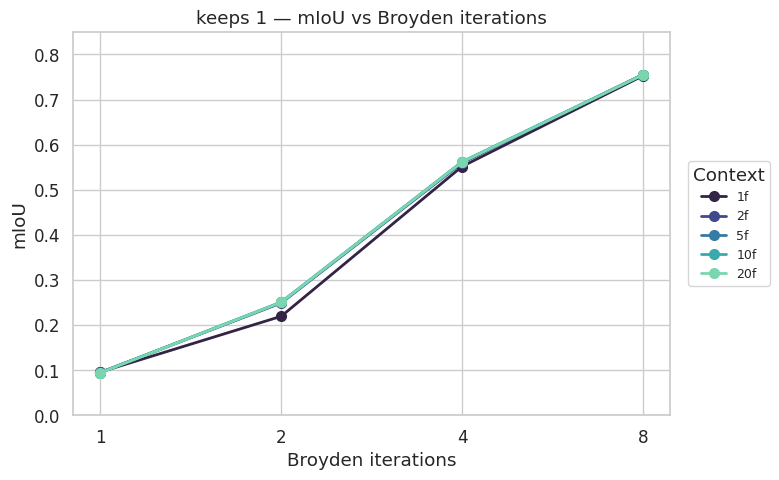

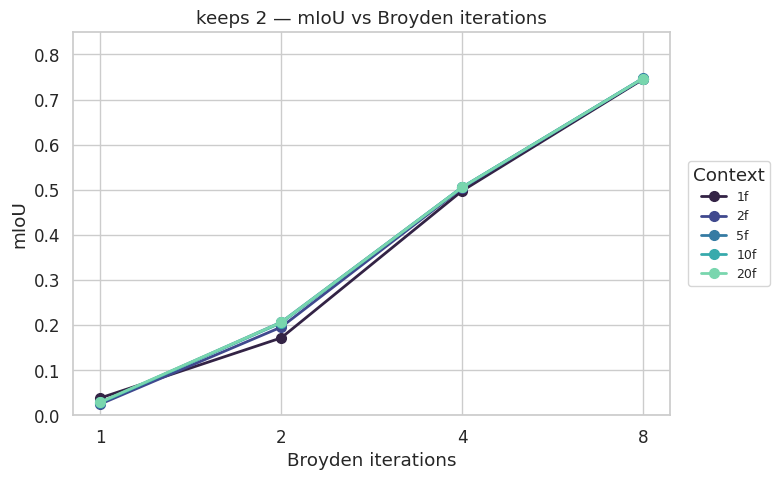

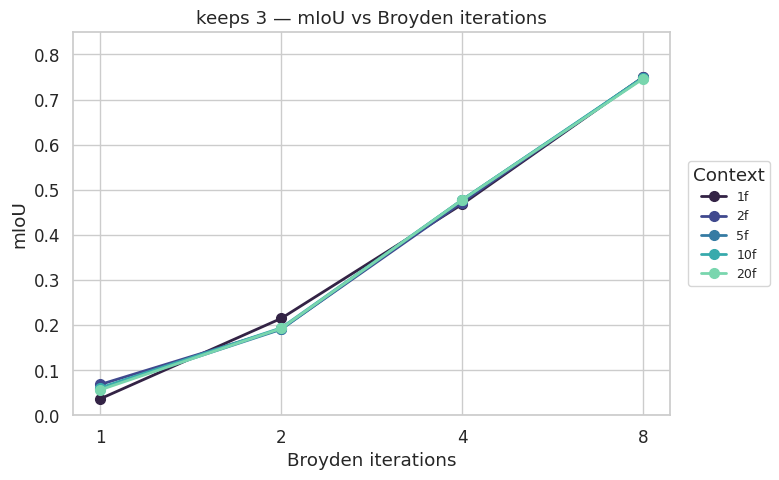

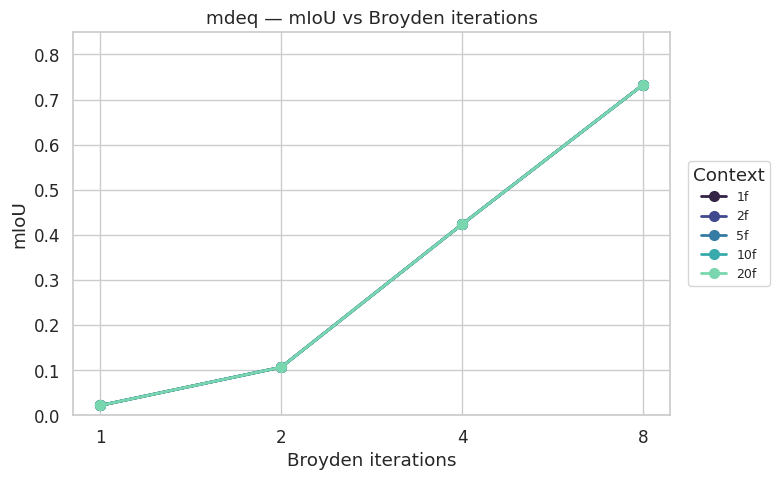

In [18]:
_mako = sns.color_palette("mako", n_colors=len(CONTEXT_ORDER))
CONTEXT_COLORS = dict(zip(CONTEXT_ORDER, _mako))

for phase, init_name in legend_keys:
    data_cfg = df[(df["phase"] == phase) & (df["init_name"] == init_name)]
    if data_cfg.empty:
        continue
    label = CONFIG_META[(phase, init_name)][0]

    fig, ax = plt.subplots(figsize=(8, 5))
    for ctx in CONTEXT_ORDER:
        sub = data_cfg[data_cfg["context"] == ctx].sort_values("broyden_iterations")
        if sub.empty:
            continue
        ax.plot(sub["broyden_iterations"], sub["miou"], color=CONTEXT_COLORS[ctx], marker="o",
                linewidth=2, markersize=7, label=ctx)
    ax.set_xscale("log")
    ax.set_xticks(ITER_ORDER)
    ax.set_xticklabels([str(i) for i in ITER_ORDER])
    ax.minorticks_off()
    ax.set_xlabel("Broyden iterations")
    ax.set_ylabel("mIoU")
    ax.set_ylim(0, 0.85)
    ax.set_title(f"{label} — mIoU vs Broyden iterations")
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9, title="Context")
    fig.tight_layout()
    plt.show()

Looking at each configuration in isolation confirms the same story from a different angle: every configuration's curve rises steeply from 1 to 4 Broyden iterations and flattens out by 8, and the darker (longer-context) lines sit furthest above the lighter ones exactly where the curve is still steep (low iterations); for configurations that already sit close to `streamdeq` (e.g. `keeps 1,2,3`), the different context lengths are almost indistinguishable, while for the weakest configurations (those without scale 1) the context lines fan out more, since there's more gap left for extra priming frames to help close.

## Overall summary

Across every way of slicing the sweep (leave-1-out, leave-2-out, leave-3-out, best/worst pairs, and marginal importance) **scale 1 is consistently the most important scale to warm-start**, by a wide margin (roughly 5x scale 0, ~1.5x scales 2/3). Scale 0 is the safest to reset every frame. This effect is strongest when the Broyden iteration budget is small; with enough iterations, the solver increasingly compensates for a worse initialization on its own, and the choice of which scales to warm-start matters progressively less. The companion notebook `equilibrium_convergence.ipynb` (and its population-scale extension `convergence_population_analysis.ipynb`) investigate a related but distinct question: how fast each scale's *internal state* converges toward its own equilibrium in isolation, and find that scale 1 is **not** the slowest-converging scale on its own, suggesting its outsized importance here comes from *how its state propagates to the other scales during fusion*, not from it individually being the hardest one to re-solve from scratch.

## Appendix: how MDEQ reaches the equilibrium z*

Reference diagram for the next experiment (per-scale convergence speed toward z\*). A rendered, styled version of this lives at:

**https://claude.ai/code/artifact/a807994a-8f94-483e-bbcc-a9c8dd981627**

If your Jupyter/VS Code viewer renders Mermaid in markdown cells, the two diagrams below will also render inline here; otherwise open the link above.

### Diagram 1 — from an image to a prediction

```mermaid
flowchart TD
    A["Cityscapes val image"] --> B["tools/seg_test.py"]
    B --> C["seg_function.py<br/>testval()"]
    C --> D["cityscapes.py<br/>multi_scale_inference() -> inference()"]
    D --> E["mdeq.py<br/>MDEQSegNet.forward(x, mode, init_mode, f_thres)"]
    E --> F{"mode?"}
    F -- "baseline (single frame)" --> G["init_state = None<br/>(cold start, deterministic)"]
    F -- "stream" --> H["_select_init_state()<br/>previous / zero / stale / partial"]
    G --> I
    H --> I["mdeq_core.py<br/>MDEQNet._forward([x, init_state], f_thres=k)"]
    I --> J["layer_utils.py<br/>list2vec: flatten + concat the 4 scales"]
    J --> K[["solvers.py<br/>broyden(func, z1, threshold=f_thres)<br/>-- see Diagram 2 --"]]
    K --> L["layer_utils.py<br/>vec2list: unflatten back to 4 scales"]
    L --> M(("z*<br/>equilibrium, 4 tensors"))
    M --> N["mdeq.py<br/>segment(z*): concat scales + conv head"]
    N --> O["class logits -> argmax"]
    O --> P["mIoU vs ground truth"]
    M -.-> Q["torch.save(z*, 'z_star.pt')<br/>~86MB, one image"]

    classDef pipeline fill:#2f6b78,stroke:#22505a,color:#ffffff;
    classDef newstep fill:#b5691f,stroke:#8f5417,color:#ffffff;
    classDef eq fill:#3f7a4d,stroke:#2e5c3a,color:#ffffff;
    class A,B,C,D,E,F,G,H,I,J,K,L,N,O,P pipeline;
    class Q newstep;
    class M eq;
```

### Diagram 2 — inside the Broyden loop

`broyden()` already tracks a single aggregate residual per step (`abs_trace` / `rel_trace`). The amber step is the small addition that splits that same residual back into the 4 scales, using the `cutoffs` the solver already computes.

```mermaid
flowchart TD
    A(("z1 = z0<br/>zeros, or previous frame if streaming")) --> B["k = 1"]
    B --> C["gx = func(z_k) - z_k<br/>residual, all 4 scales flattened together"]
    C --> D["split gx by cutoffs -> gx0, gx1, gx2, gx3<br/>||gx_i|| per scale"]
    D --> E["MSE(z_k[i], z*[i]) per scale<br/>using the saved z*"]
    E --> F{"||gx|| < eps (1e-3)?<br/>or k = f_thres?"}
    F -- no --> G["Broyden low-rank update<br/>(Us, VTs) -> z_k+1"]
    G --> H["k = k + 1"]
    H --> C
    F -- yes --> I(("z* = z_k<br/>equilibrium"))

    classDef pipeline fill:#2f6b78,stroke:#22505a,color:#ffffff;
    classDef newstep fill:#b5691f,stroke:#8f5417,color:#ffffff;
    classDef eq fill:#3f7a4d,stroke:#2e5c3a,color:#ffffff;
    class A,B,C,F,G,H pipeline;
    class D,E newstep;
    class I eq;
```

### Reading the two diagrams together

Run Diagram 1 once with a high `f_thres` (e.g. 27, matching the existing `sf_27i` baseline) to get and save z\* for one image. Then run it again with `f_thres = 1, 2, 3, ...`. Each run replays the same deterministic prefix of the loop in Diagram 2, so the amber step gives four MSE-vs-iteration curves, one per scale, without ever holding more than one iteration's state in memory at a time.

**Optional extension:** for a per-scale mIoU instead of just MSE, at iteration k build a hybrid state where only scale `i` keeps `z_k[i]` and the other three are swapped for their converged `z*[j]`, then run that through `segment()`. Repeating per scale turns the single mIoU arrow in Diagram 1 into four "mIoU if only this scale hadn't converged yet" curves, directly comparable to the MSE curves from Diagram 2.

### Code map

| File | What lives there |
|---|---|
| `lib/models/mdeq.py` | `MDEQSegNet.forward()` and `segment()` — entry point and segmentation head |
| `lib/models/mdeq_core.py` | `MDEQNet._forward()` — builds the injection, calls the solver, unflattens the result |
| `lib/solvers.py` | `broyden()` — the fixed-point iteration itself, already returns a per-step residual trace |
| `lib/layer_utils.py` | `list2vec()` / `vec2list()` — the flatten/unflatten that concatenates the 4 scales contiguously |
| `lib/core/seg_function.py` | `testval()` — the evaluation loop this notebook's results come from |
| `lib/datasets/cityscapes.py` | `multi_scale_inference()` / `inference()` — per-frame plumbing between the eval loop and the model |


### Diagram 3 — how `drop_scaleK` behaves *across frames* (not just within one)

Diagrams 1 and 2 above show a single forward call. This one answers a question that only makes sense once you zoom out to a whole streaming sequence: for `PARTIAL_INIT_MODE='drop_scale0_previous'`, does scale 0 only start cold on the very first frame, or does that keep happening?

**Teal = carried forward warm. Red = reset to zero every single frame, not just once.** `_build_partial_init_state()` (`lib/models/mdeq.py`) re-runs from scratch on *every* frame, and for `drop_scale0_previous` it only ever copies indices `[1, 2, 3]` from `self.prev_outs` — index 0 is always rebuilt as `zeros_like(...)` first and never overwritten. Frame 1 is the one exception, and not because of anything scale-0-specific: `self.prev_outs` is simply `None` there (nothing exists yet), so *all four* scales start cold, and the drop-scale-0 rule doesn't even get a chance to run yet.

```mermaid
flowchart TB
    subgraph F1["Frame 1 (prev_outs is None -- ALL 4 scales cold, not just scale 0)"]
        A1["init_state = None"] --> B1["Broyden solve<br/>(4 scales fuse every iteration)"] --> C1["equilibrium y1 = [z0, z1, z2, z3]"]
    end
    C1 --> D1["self.prev_outs = y1<br/>(all 4 scales stored, unconditionally)"]

    subgraph F2["Frame 2"]
        E2["_build_partial_init_state(prev_outs, 'drop_scale0_previous')"]
        F2z["scale 0 -> 0<br/>(reset)"]
        F2k["scales 1,2,3 -> prev_outs[1,2,3]<br/>(reused warm)"]
        E2 --> F2z
        E2 --> F2k
        F2z --> G2["Broyden solve"]
        F2k --> G2
        G2 --> H2["equilibrium y2 = [z0, z1, z2, z3]"]
    end
    D1 -. "y1[0] discarded, never read again" .-> F2z
    D1 -- "y1[1..3] reused" --> F2k
    H2 --> I2["self.prev_outs = y2"]

    subgraph F3["Frame 3 (and every frame after)"]
        E3["_build_partial_init_state(prev_outs, 'drop_scale0_previous')"]
        F3z["scale 0 -> 0<br/>(reset again)"]
        F3k["scales 1,2,3 -> prev_outs[1,2,3]<br/>(reused warm)"]
        E3 --> F3z
        E3 --> F3k
    end
    I2 -. "y2[0] discarded, never read again" .-> F3z
    I2 -- "y2[1..3] reused" --> F3k

    classDef neutral fill:#6b7280,stroke:#4b5158,color:#ffffff;
    classDef kept fill:#2f6b78,stroke:#22505a,color:#ffffff;
    classDef reset fill:#a33b3b,stroke:#7a2b2b,color:#ffffff;
    class A1,B1,C1,D1,E2,G2,H2,I2,E3 neutral;
    class F2k,F3k kept;
    class F2z,F3z reset;
```

**The part that's easy to miss**: scale 0 *does* reach a real equilibrium every single frame (the Broyden solve always runs on all 4 fused scales, regardless of how they were initialized — see Diagram 1). That value gets stored in `self.prev_outs[0]` just like the others. It's just that the *next* frame's `_build_partial_init_state()` never reads `prev_outs[0]` back out, so it's computed and immediately thrown away, over and over, for the rest of the sequence.

**Fusion is completely unaffected.** `PARTIAL_INIT_MODE` never touches `MDEQModule.forward()` / `fullstage` (`lib/models/mdeq_core.py`) — the up/down-sample-and-sum fuse step runs identically on every iteration of every frame no matter which scales were warm-started. The only thing that changes is `z^(0)`, the starting point handed to Broyden for that frame. That's also *why* `drop_scale0_previous` barely hurts mIoU compared to full `previous`: because everything fuses together every iteration, a cold scale 0 gets pulled toward the right neighborhood by the three warm scales almost immediately, rather than having to re-discover it alone.